In [1]:
import sys

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plts
import yaml

from pmt.io import *
from scipy.signal import find_peaks

from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *
from pmt.selection import *
from pmt.fit import *
from pmt.fit.core import *

from pmt.fit.poisson import fit_poisson_spe, poisson_npe_fractions
from pmt.fit.bellamy import fit_bellamy_spe

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


# Select Files


In [2]:
date = "260709"

channel="Channel 4"
data_dir = Path(f"data/WA0089/voltage_sweep/{date}")
# Set to a number for quick iteration, or None to use all matching files.
max_files = None


inputV = 750 # 750 775 800..1000
file_name = f"WA0089_{inputV}V_20MHz_led100" 

# save
save_plots = True
save_dir = f'plots/{date}/fit'
file_nickname = f"{file_name}"
fit_inputs = f"fit_data/{date}"

save_fit_res = "fit_results"
savefit_path = Path(f"{save_dir}/{save_fit_res}")
savefit_path.mkdir(parents=True, exist_ok=True)


In [3]:
df_file = Path(fit_inputs) / f"{file_nickname}_df.pkl"

if df_file.exists():
    print(f"Loading cached dataframe from {df_file}")
    df = pd.read_pickle(df_file)
else:
    print("Creating dataframe from raw waveforms...")
    chunk_size = 512 
    baseline_window_ns = (0, 20)
    files = find_pmt_files(data_dir, file_name, max_files=max_files)
    for file in files:
        print(file)
    print(f"Number of files loaded: {len(files)}")
    time_ns, waveforms_mV, df = load_files_one_go( files, chunk_size, baseline_window_ns, channel )
print(df.shape)

Loading cached dataframe from fit_data/260709/WA0089_750V_20MHz_led100_df.pkl
(299994, 33)


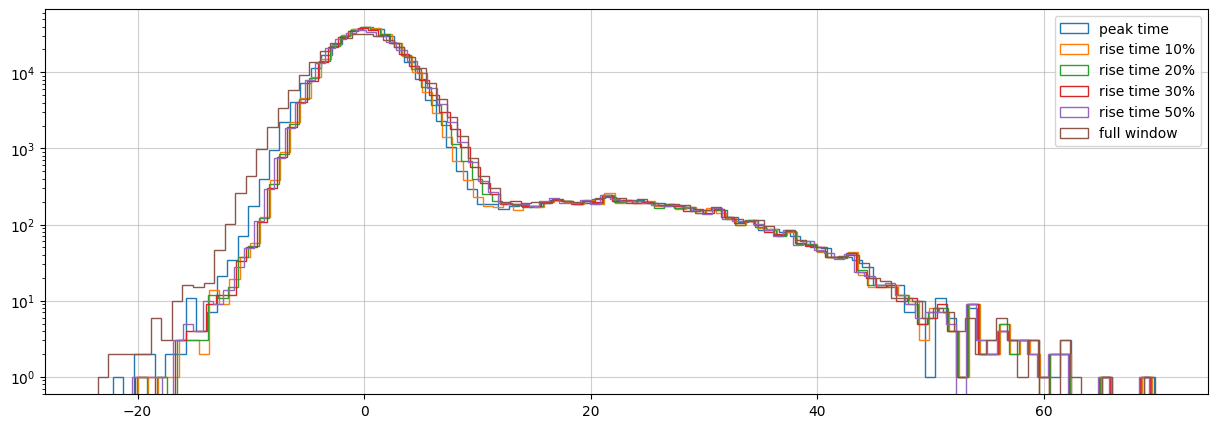

In [4]:
fig, axes = plt.subplots(1, 1, figsize=(15, 5))

rg = None #(-20, 10)
den=False

axes.hist(df.charge_peak_window_mV_ns,  bins=100, range=rg, density=den, histtype='step', label="peak time");
axes.hist(df.charge_cfd10_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 10%");
axes.hist(df.charge_cfd20_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 20%");
axes.hist(df.charge_cfd30_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 30%");
axes.hist(df.charge_cfd50_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 50%");
axes.hist(df.area_mV_ns,                bins=100, range=rg, density=den, histtype='step', label="full window");
axes.set_yscale('log');
axes.legend();




# Fit one step

In [5]:
charge_mV_ns = df.charge_cfd50_window_mV_ns.values # chose one charge distribution
fit_range_full = (np.min(charge_mV_ns), np.max(charge_mV_ns))
print(f"full range = ({fit_range_full[0]:.2f}, {fit_range_full[1]:.2f})")
fit_range = fit_range_full #(-16, 90)

full range = (-20.50, 69.34)


In [6]:
bins_list = [50, 75, 100, 150, 200, 250, 300, 400, 500, 600, 700, 800, 900, 1000]
_ = scan_binning( charge_mV_ns, bins_list, fit_range=fit_range )
# _ = binning_diagnostics( charge_mV_ns, 250, fit_range=fit_range, verbose=True )

  Bins     Width      Mean    Median    Empty%       <5%     Min     Max
------------------------------------------------------------------------
    50       1.8    5999.9     185.0       4.0      16.0       0   70024
    75       1.2    3999.9     130.0       6.7      21.3       0   46324
   100     0.898    2999.9      94.5       8.0      24.0       0   35588
   150     0.599    2000.0      65.5      10.0      28.0       0   23822
   200     0.449    1500.0      47.0      12.0      30.0       0   17822
   250     0.359    1200.0      37.5      14.4      31.6       0   14303
   300     0.299    1000.0      31.5      15.0      33.3       0   12011
   400     0.225     750.0      23.0      18.0      36.5       0    9042
   500      0.18     600.0      19.0      20.4      37.8       0    7249
   600      0.15     500.0      15.5      21.7      39.5       0    6011
   700     0.128     428.6      13.0      22.7      40.4       0    5233
   800     0.112     375.0      11.0      24.4     

In [7]:
nbins = 250
_ = binning_diagnostics( charge_mV_ns, nbins, fit_range=fit_range )

Binning diagnostics
----------------------------------------
Entries              : 299994
Bins                 : 250
Bin width            : 0.3593
Min count/bin        : 0
Max count/bin        : 14303
Mean count/bin       : 1199.98
Median count/bin     : 37.50
Empty bins           : 36 (14.4%)
Bins with <5 counts  : 79 (31.6%)


# Fit Config

In [8]:
def get_initPars(cfg, file_key, fit_model, default_key):
    default = cfg[default_key][fit_model]["initPars"]
    user = ( cfg.get(file_key, {}).get(fit_model, {}).get("initPars", {}) )
    return {**default, **user}

In [9]:
with open('config_files/fit_config.yaml') as f:
    cfg = yaml.safe_load(f)

## Poisson

In [10]:
p0_poisson = get_initPars( cfg, file_name, fit_model="poisson", default_key="WA0089_20MHz_led100_defaults")
try:
    fit_rg = cfg[file_name]['fit_range']
    print(f'Fit range = {fit_rg}')
except:
    print('No fit range specified, using full range')
    fit_rg = fit_range_full
maxPE = 3
p0_poisson["n_total"] = [len(charge_mV_ns), 0.5 * len(charge_mV_ns), 1.5 * len(charge_mV_ns), False]

No fit range specified, using full range


Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         299994.0000 297437.3281     545.4043   [149997.0, 449991.0]   False
mu_pe                0.0600      0.0255       0.0004             [0.0, 5.0]   False
q0_mV_ns             0.3000      0.3009       0.0056            [-5.0, 5.0]   False
sigma0_mV_ns         3.9000      2.9325       0.0041            [0.0, 10.0]   False
q1_mV_ns            29.0000     18.0997       0.2550           [5.0, 200.0]   False
sigma1_mV_ns        12.0000     11.2209       0.1566            [1.0, 80.0]   False

 Gain is 2.26e+06 +-3.18e+04 for Q1 = 18.09968159769189


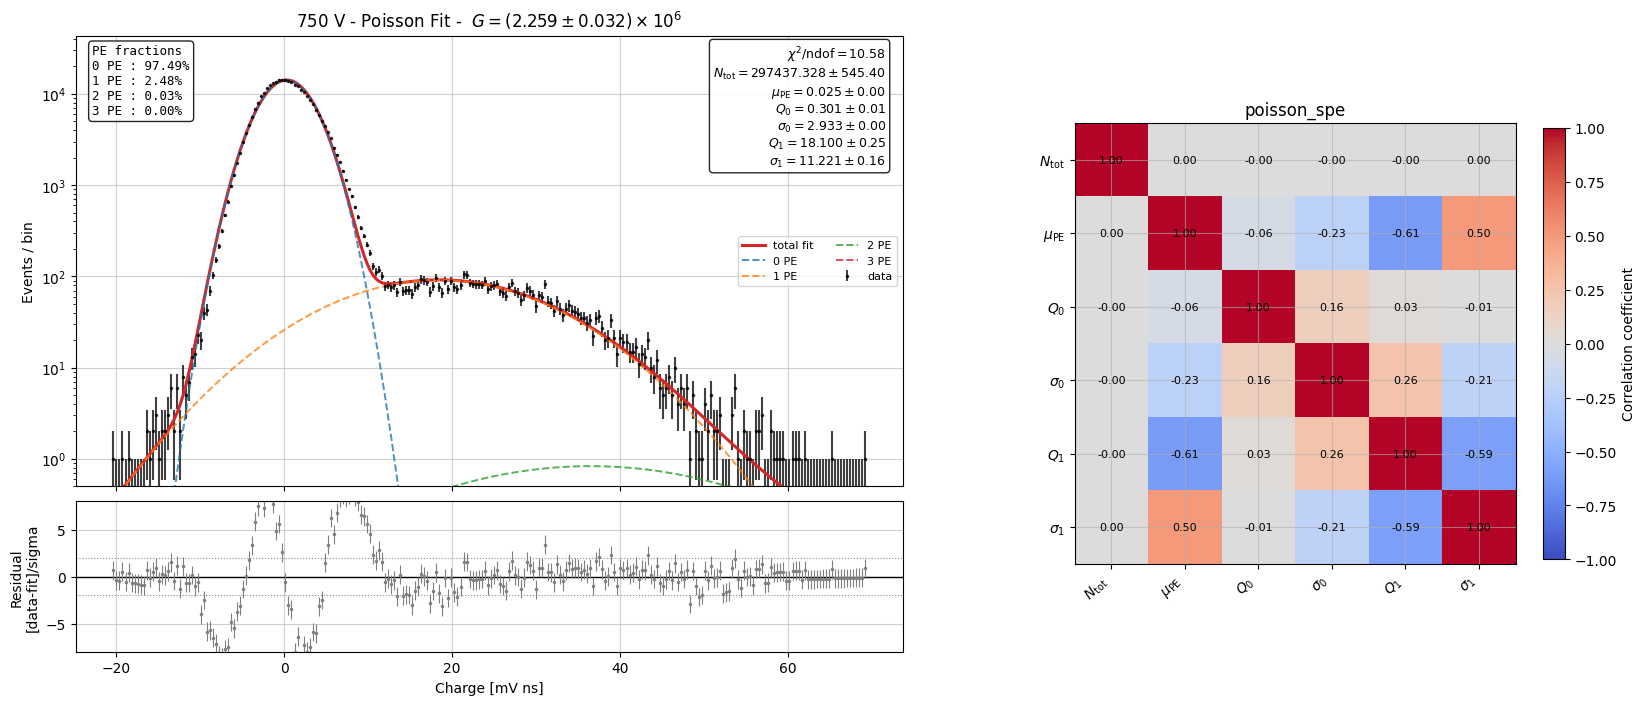

In [11]:
fit_poisson = fit_poisson_spe( charge_mV_ns, p0=p0_poisson, max_pe=maxPE, bins=nbins, fit_range=fit_rg )
print_fit_result_table(fit_poisson)
if fit_poisson["diagnostics"] != []:
    print(fit_poisson["diagnostics"])


G, G_err = compute_gain(fit_poisson['parameters']['q1_mV_ns'], fit_poisson['errors']['q1_mV_ns'])
print(f"\n Gain is {G:.3g} +-{G_err:.2e} for Q1 = {fit_poisson['parameters']['q1_mV_ns']}")
exp = 6
G_scaled = G / 10**exp
Gerr_scaled = G_err / 10**exp
title = fr"{inputV} V - Poisson Fit -  $G = ({G_scaled:.3f} \pm {Gerr_scaled:.3f}) \times 10^{exp}$"

fig, ax_fit, ax_resid, ax_corr = plot_fit_summary( fit_poisson, title=title, shrink_colorbar=0.7, component_visibility_fraction=0, logscale=True,
                                                  show_event_fractions=True, max_fraction_pe=maxPE) 

# save_plot(fig, save_plots, save_dir, file_nickname, f"fit_Poisson_{nbins}bins",  Nevents=None);
# save_fit_results(fit_poisson, output_path=f"{savefit_path}/{file_nickname}_poisson.yaml");


## Bellamy

In [12]:
p0_bellamy = get_initPars( cfg, file_name, fit_model="bellamy", default_key="WA0089_20MHz_led100_defaults")
try:
    fit_rg = cfg[file_name]['fit_range']
    print(f'Fit range = {fit_rg}')
except:
    print('No fit range specified, using full range')
    fit_rg = fit_range_full
maxPE = 3
p0_bellamy["n_total"] = [len(charge_mV_ns), 0.5 * len(charge_mV_ns), 1.5 * len(charge_mV_ns), False]
p0_bellamy

No fit range specified, using full range


{'q0_mV_ns': [-1.3, -5.0, 5.0, False],
 'sigma0_mV_ns': [2.6, '1e-4', 10.0, False],
 'q1_mV_ns': [29.0, 5.0, 200.0, False],
 'sigma1_mV_ns': [12.0, 1.0, 80.0, False],
 'mu_pe': [0.06, 0.001, 5.0, False],
 'w': [1.0, 0.0, 1.0, True],
 'alpha': [0.3, 0.0, 10.0, False],
 'n_total': [299994, 149997.0, 449991.0, False]}

Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         299994.0000 299367.0168     547.1564   [149997.0, 449991.0]   False
mu_pe                0.0600      0.0183       0.0004             [0.0, 5.0]   False
q0_mV_ns            -1.3000     -1.2658       0.0148            [-5.0, 5.0]   False
sigma0_mV_ns         2.6000      2.5712       0.0073            [0.0, 10.0]   False
q1_mV_ns            29.0000     22.8984       0.2608           [5.0, 200.0]   False
sigma1_mV_ns        12.0000      8.9816       0.1999            [1.0, 80.0]   False
w                    1.0000      1.0000       0.0000             [1.0, 1.0]    True
alpha                0.3000      0.6202       0.0059            [0.0, 10.0]   False


 Gain is 2.86e+06 +-3.26e+04 for Q1 = 22.89838743505898


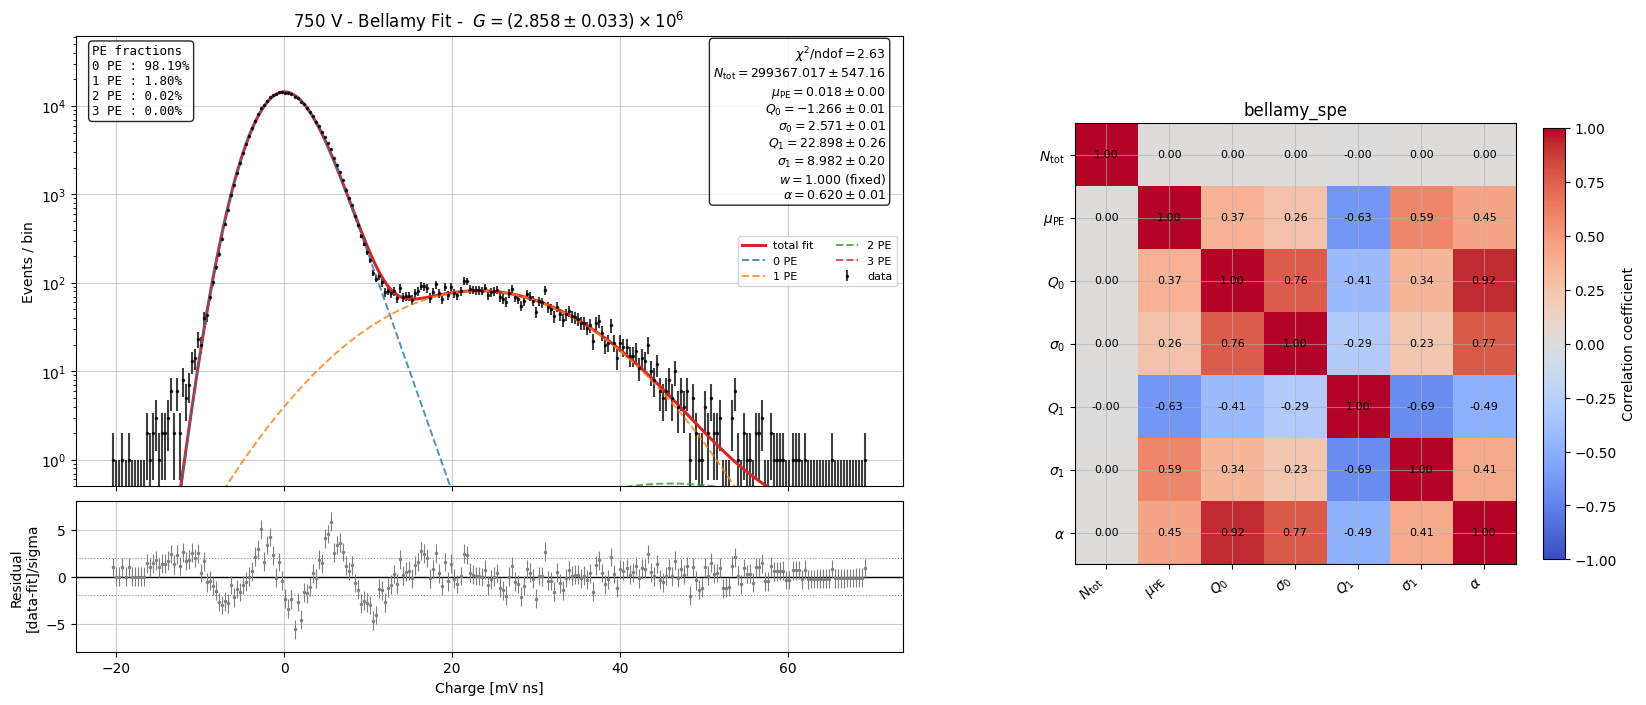

In [13]:

fit_bellamy = fit_bellamy_spe( charge_mV_ns, p0=p0_bellamy, max_pe=maxPE, bins=nbins, fit_range=fit_rg)
print_fit_result_table(fit_bellamy)
print()
if fit_bellamy["diagnostics"] != []:
    print(fit_bellamy["diagnostics"])

G, G_err = compute_gain(fit_bellamy['parameters']['q1_mV_ns'], fit_bellamy['errors']['q1_mV_ns'])
print(f"\n Gain is {G:.3g} +-{G_err:.2e} for Q1 = {fit_bellamy['parameters']['q1_mV_ns']}")
exp = 6
G_scaled = G / 10**exp
Gerr_scaled = G_err / 10**exp
title = fr"{inputV} V - Bellamy Fit -  $G = ({G_scaled:.3f} \pm {Gerr_scaled:.3f}) \times 10^{exp}$"

fig, ax_fit, ax_resid, ax_corr = plot_fit_summary( fit_bellamy, title=title, shrink_colorbar=0.7, component_visibility_fraction=0, logscale=True,
                                                  show_event_fractions=True, max_fraction_pe=maxPE) 

# save_plot(fig, save_plots, save_dir, file_nickname, f"fit_Bellamy_{nbins}bins",  Nevents=None);
# save_fit_results(fit_bellamy, output_path=f"{savefit_path}/{file_nickname}_bellamy.yaml")


# Perform several fits

In [14]:

def fit_charge(inputV, file_name, fit_inputs, cfg, save_dir, maxPE=3, nbins=250, fit_model="poisson", default_key="WA0089_20MHz_led100_defaults", lbl=None, save_results=False, initPars=None):

    #--- save stuff
    save_fitresults = Path(f"{save_dir}/fit_results")
    save_fitresults.mkdir(parents=True, exist_ok=True)
    save_fitplots = Path(f"{save_dir}/fit_plots")
    save_fitplots.mkdir(parents=True, exist_ok=True)

    #--- load dataframe
    df_file = Path(fit_inputs) / f"{file_name}_df.pkl"
    print(f"\nLoading cached dataframe from {df_file}")
    df = pd.read_pickle(df_file)

    #--- fit variable
    charge_mV_ns = df.charge_cfd50_window_mV_ns.values 
    fit_range_full = (np.min(charge_mV_ns), np.max(charge_mV_ns))

    #--- initial parameters
    if initPars is None:
        initPars = get_initPars( cfg, file_name, fit_model, default_key)
    try:
        fit_rg = cfg[file_name]['fit_range']
        print(f'Fit range = {fit_rg}')
    except:
        fit_rg = fit_range_full
        print(f'No fit range specified, using full range {fit_rg}')
    initPars["n_total"] = [len(charge_mV_ns), 0.5 * len(charge_mV_ns), 1.5 * len(charge_mV_ns), False]
    #--- perform fit
    model_name=""
    if fit_model=="poisson":
        model_name = "Poisson"
        fit = fit_poisson_spe( charge_mV_ns, p0=initPars, max_pe=maxPE, bins=nbins, fit_range=fit_rg )
    elif fit_model=="bellamy":
        model_name = "Bellamy"
        fit = fit_bellamy_spe( charge_mV_ns, p0=initPars, max_pe=maxPE, bins=nbins, fit_range=fit_rg )
    print_fit_result_table(fit)
    if fit["diagnostics"] != []:
        print(fit["diagnostics"])

    G, G_err = compute_gain(fit['parameters']['q1_mV_ns'], fit['errors']['q1_mV_ns'])
    print(f"\n Gain is {G:.3g} +-{G_err:.2e} for Q1 = {fit['parameters']['q1_mV_ns']}")
    exp = 6
    G_scaled = G / 10**exp
    Gerr_scaled = G_err / 10**exp
    title = fr"{inputV} V - {model_name} Fit -  $G = ({G_scaled:.3f} \pm {Gerr_scaled:.3f}) \times 10^{exp}$"

    fig, _, _, _ = plot_fit_summary( fit, title=title, shrink_colorbar=0.7, component_visibility_fraction=0, logscale=True,
                                                    show_event_fractions=True, max_fraction_pe=maxPE) 

    if save_results:
        saveplot = f"fit_{model_name}_{nbins}bins"
        saveres = f"{file_name}_{model_name}"
        if lbl is not None:
            saveplot += f"f_{lbl}"
            saveres  += f"f_{lbl}"
        save_plot(fig, True, save_fitplots, file_name, saveplot,  Nevents=None);
        save_fit_results(fit, output_path=f"{save_fitresults}/{saveres}.yaml");


### Poisson

In [15]:
# date = "260709"
# fit_inputs = f"fit_data/{date}"
# save_dir = f'plots/{date}/fit'
# with open('config_files/fit_config.yaml') as f:
#     cfg = yaml.safe_load(f)

# inputV = 775
# file_name = f"WA0089_{inputV}V_20MHz_led100" 
# fit_charge(inputV, file_name, fit_inputs, cfg, save_dir, maxPE=3, nbins=250, fit_model="poisson", default_key="WA0089_20MHz_led100_defaults", save_results=False)



Loading cached dataframe from fit_data/260709/WA0089_750V_20MHz_led100_df.pkl
No fit range specified, using full range (np.float64(-20.50187611230649), np.float64(69.33517225878313))
Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         299994.0000 297437.3281     545.4043   [149997.0, 449991.0]   False
mu_pe                0.0600      0.0255       0.0004             [0.0, 5.0]   False
q0_mV_ns             0.3000      0.3009       0.0056            [-5.0, 5.0]   False
sigma0_mV_ns         3.9000      2.9325       0.0041            [0.0, 10.0]   False
q1_mV_ns            29.0000     18.0997       0.2550           [5.0, 200.0]   False
sigma1_mV_ns        12.0000     11.2209       0.1566            [1.0, 80.0]   False

 Gain is 2.26e+06 +-3.18e+04 for Q1 = 18.09968159769189

Loading cached dataframe from fit_data/260709/WA0089_775V_20MHz_led100_df.pkl
No fit range

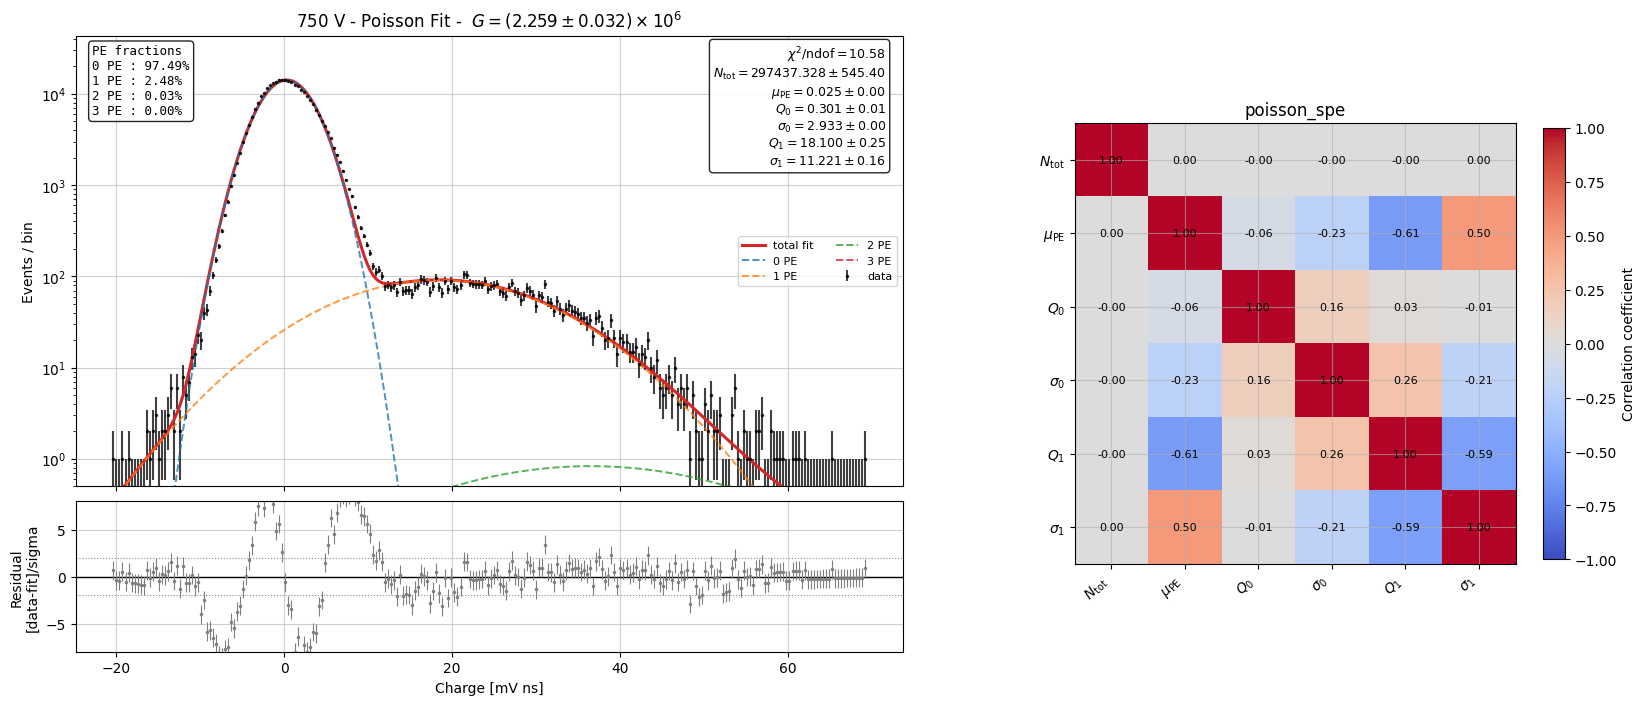

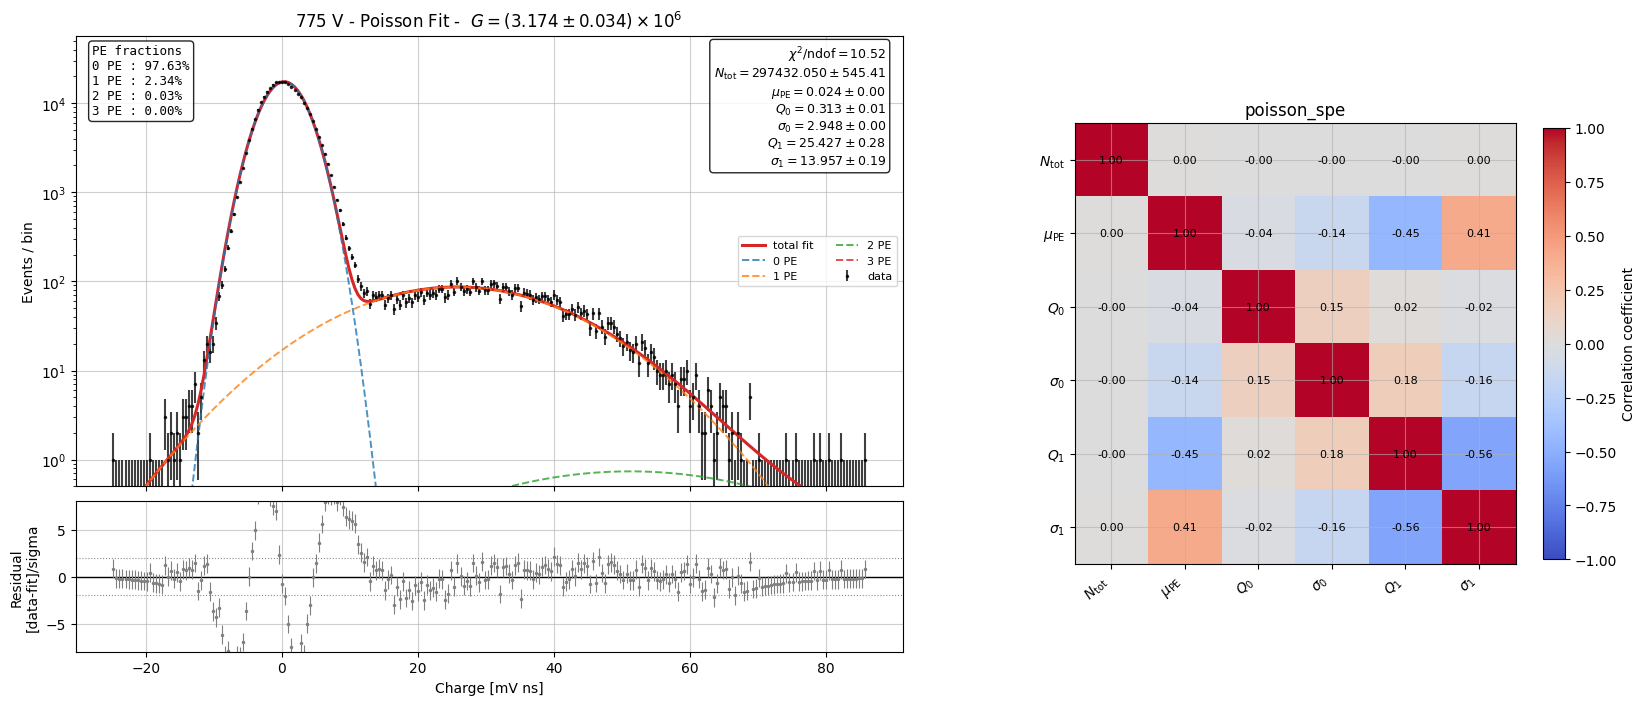

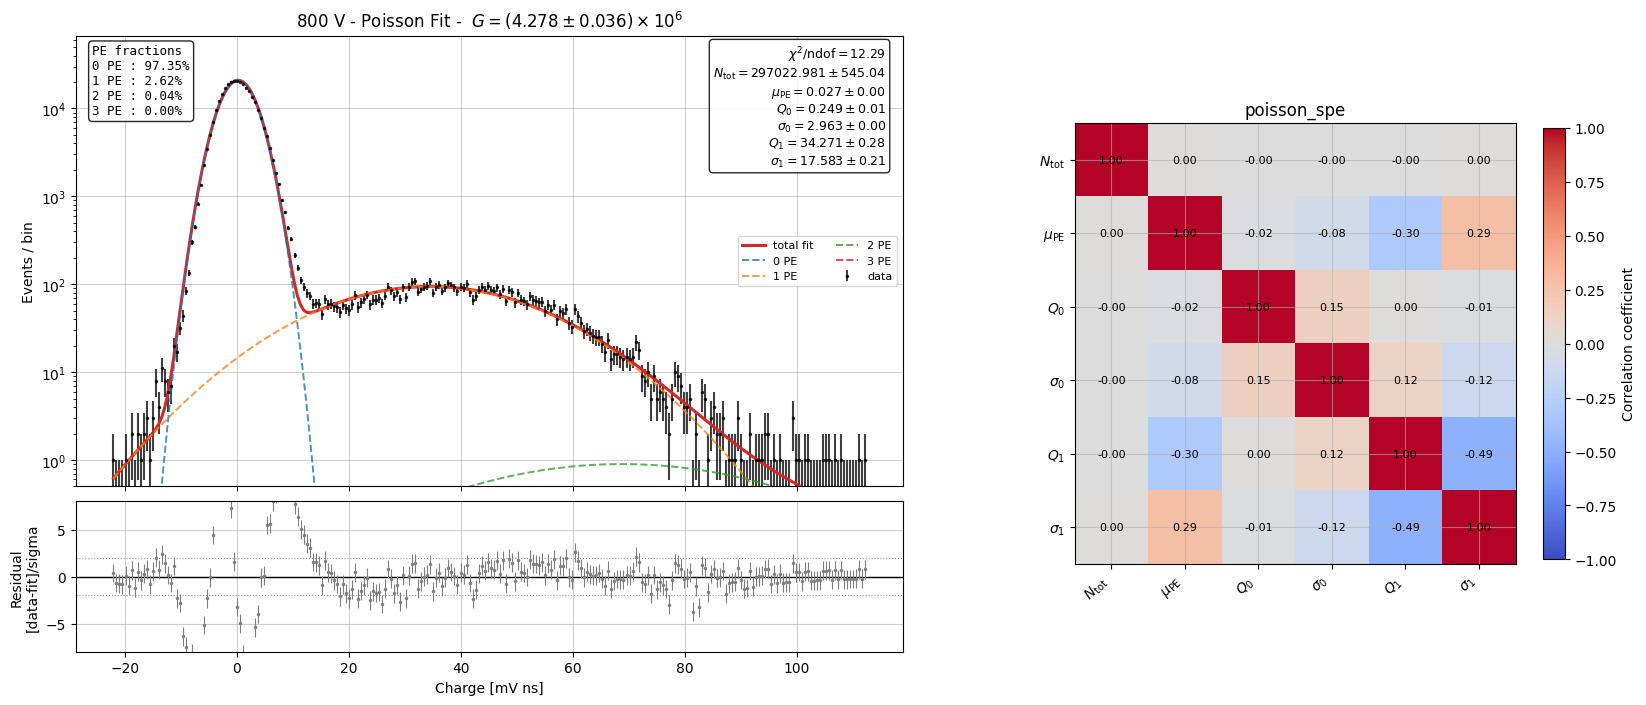

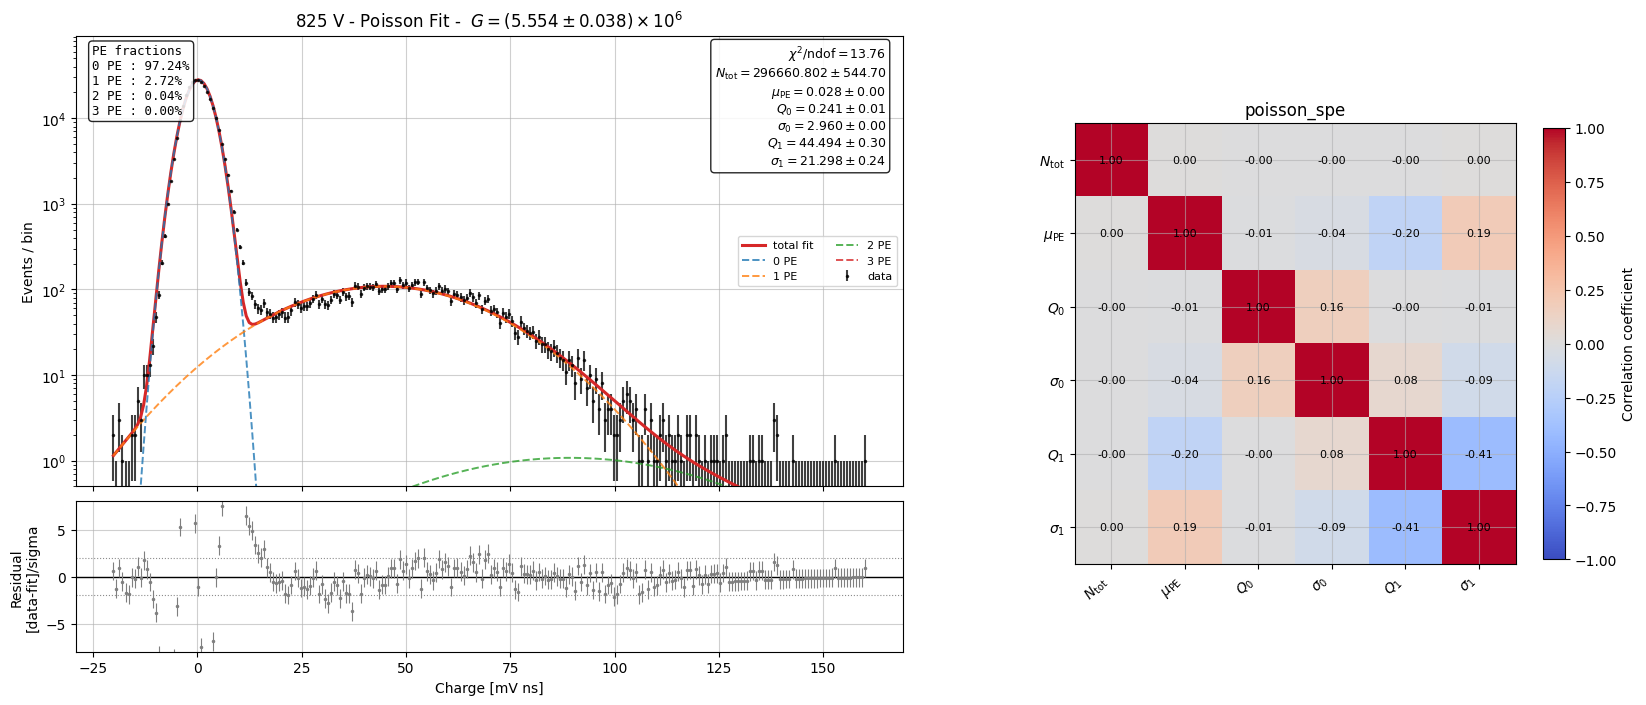

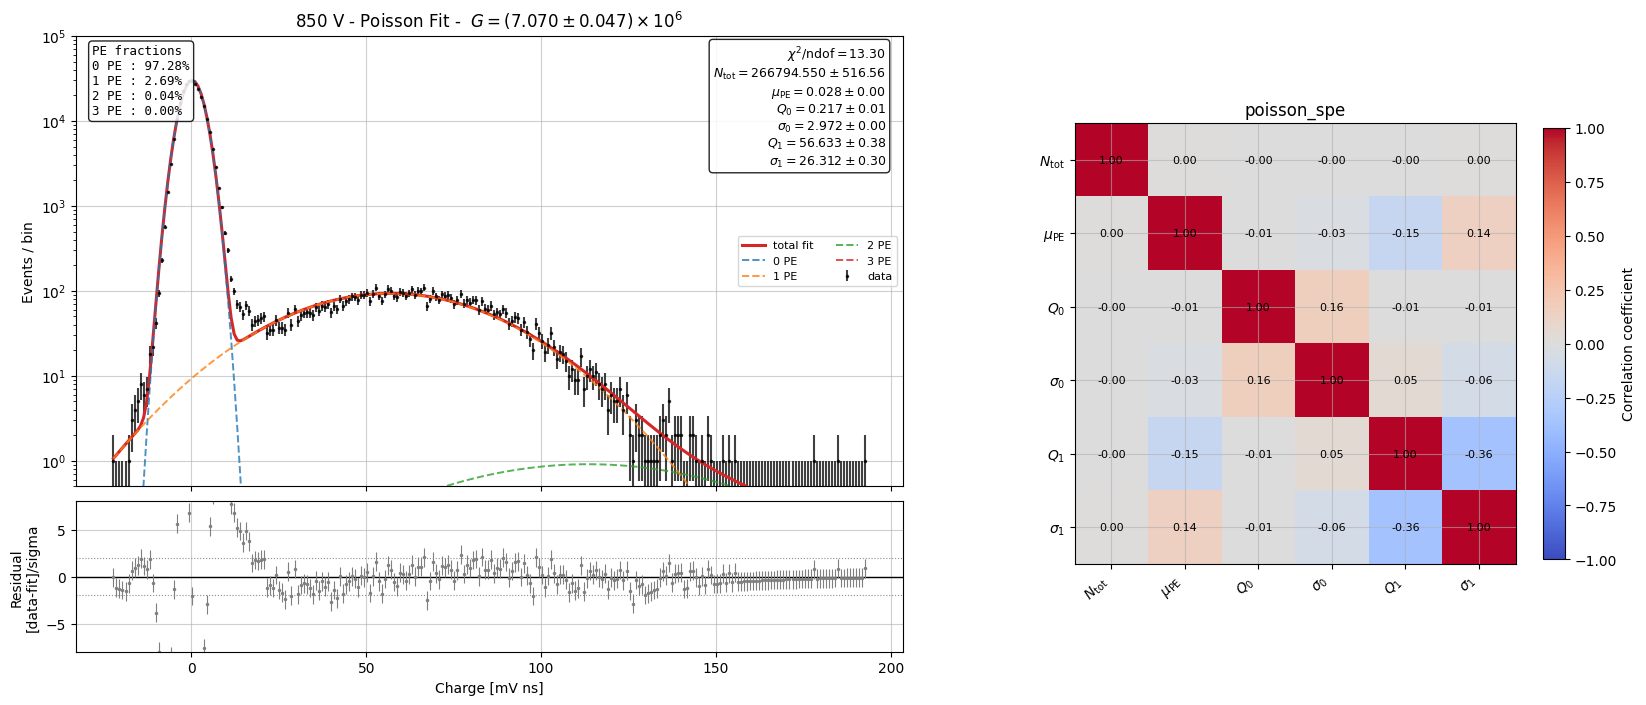

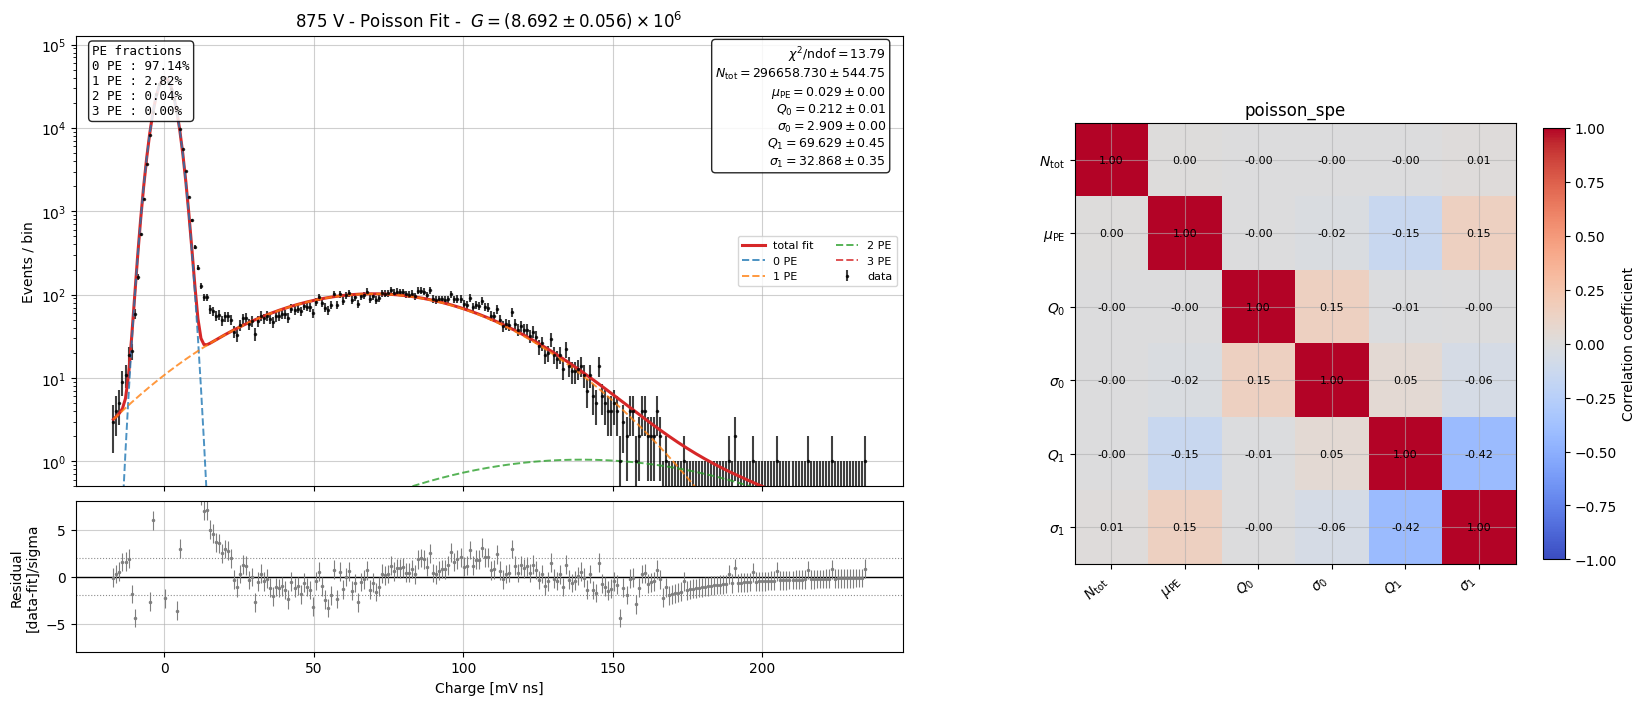

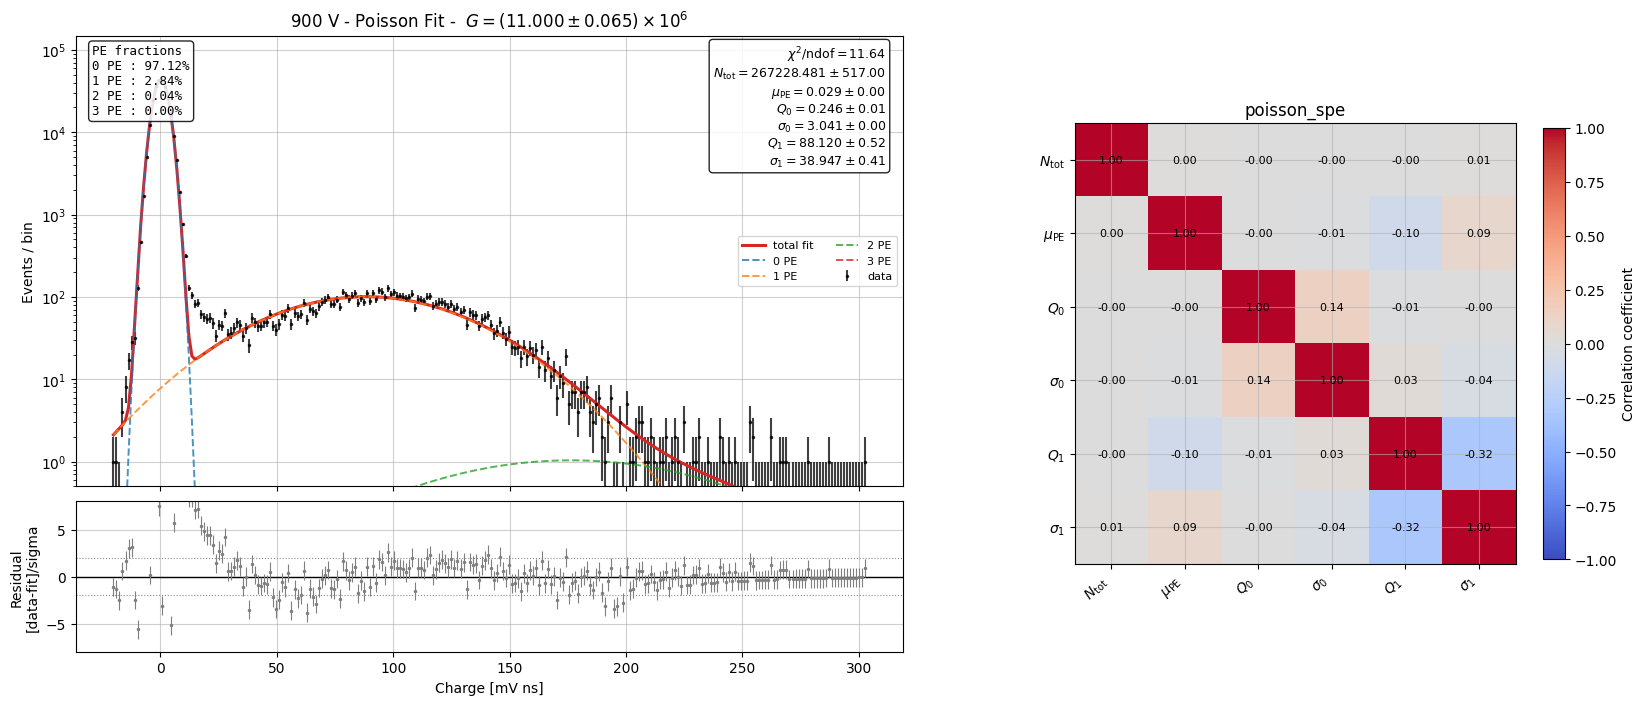

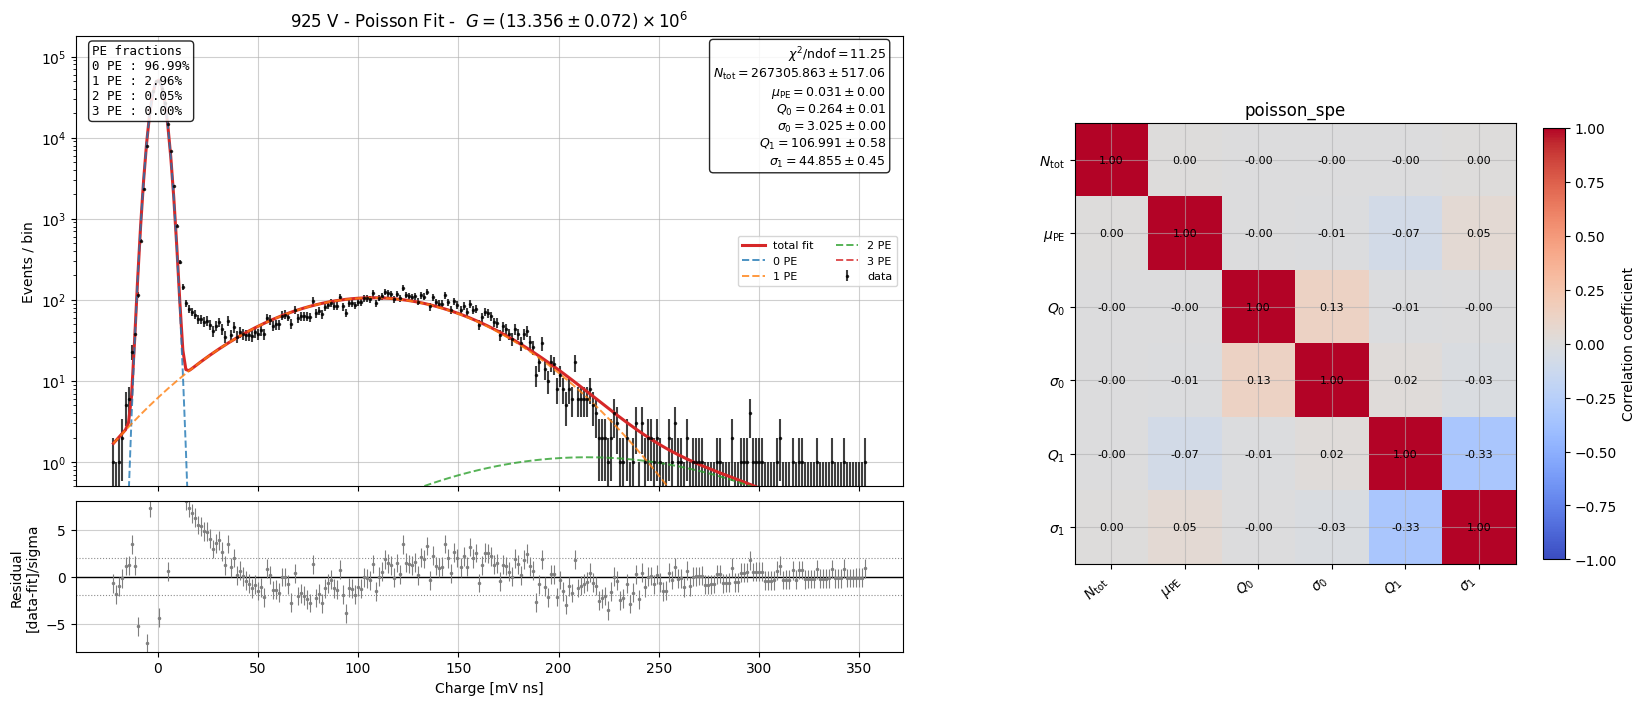

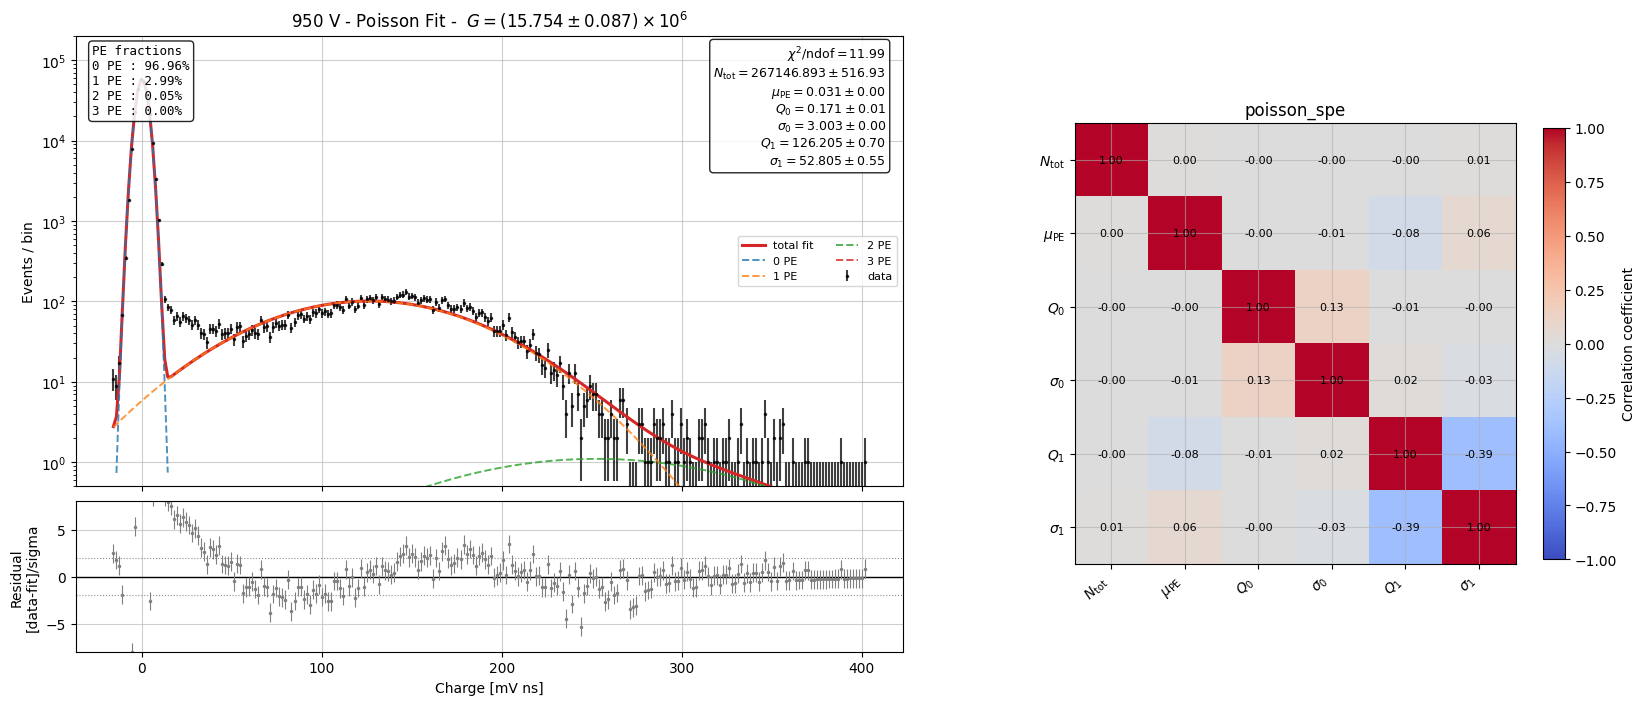

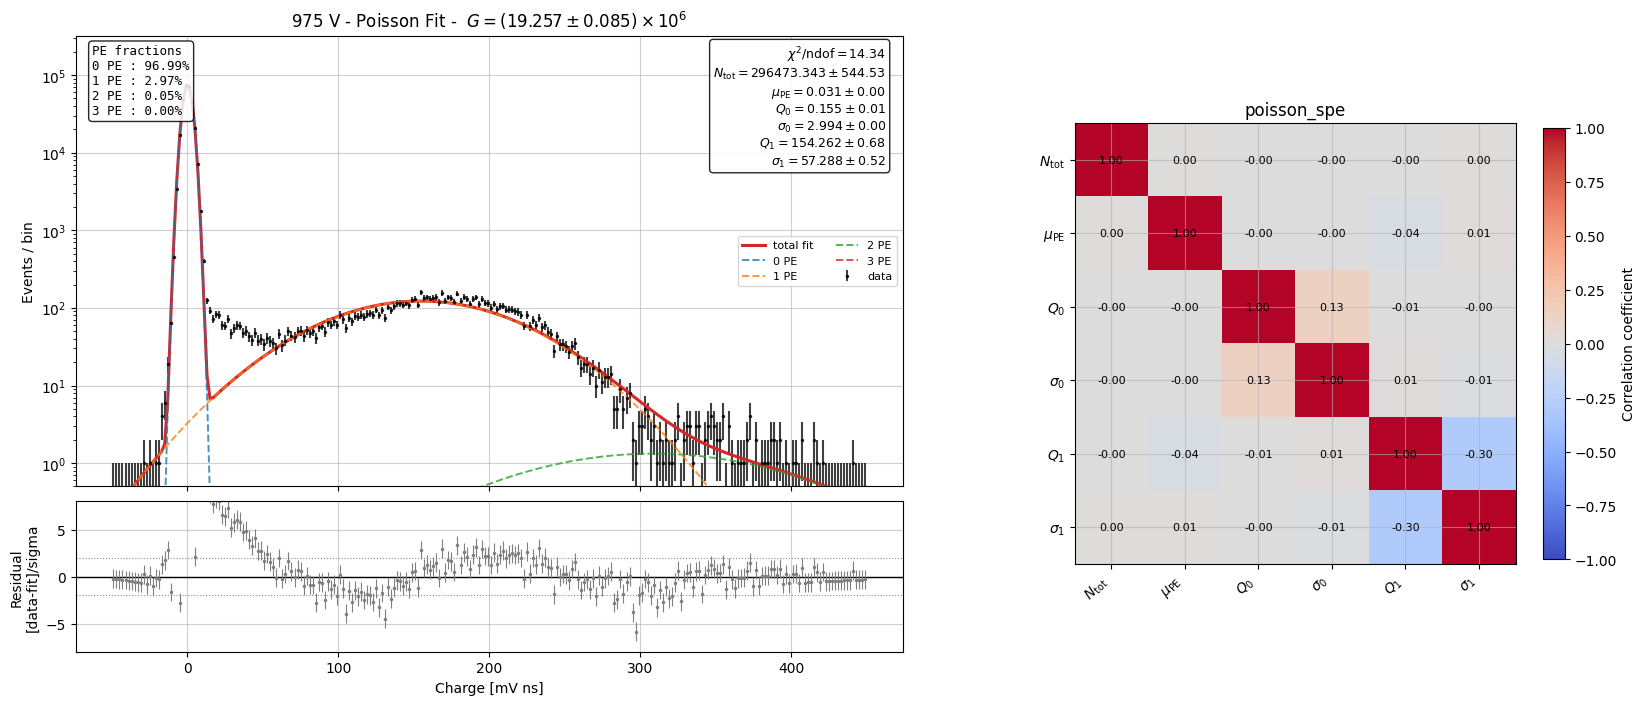

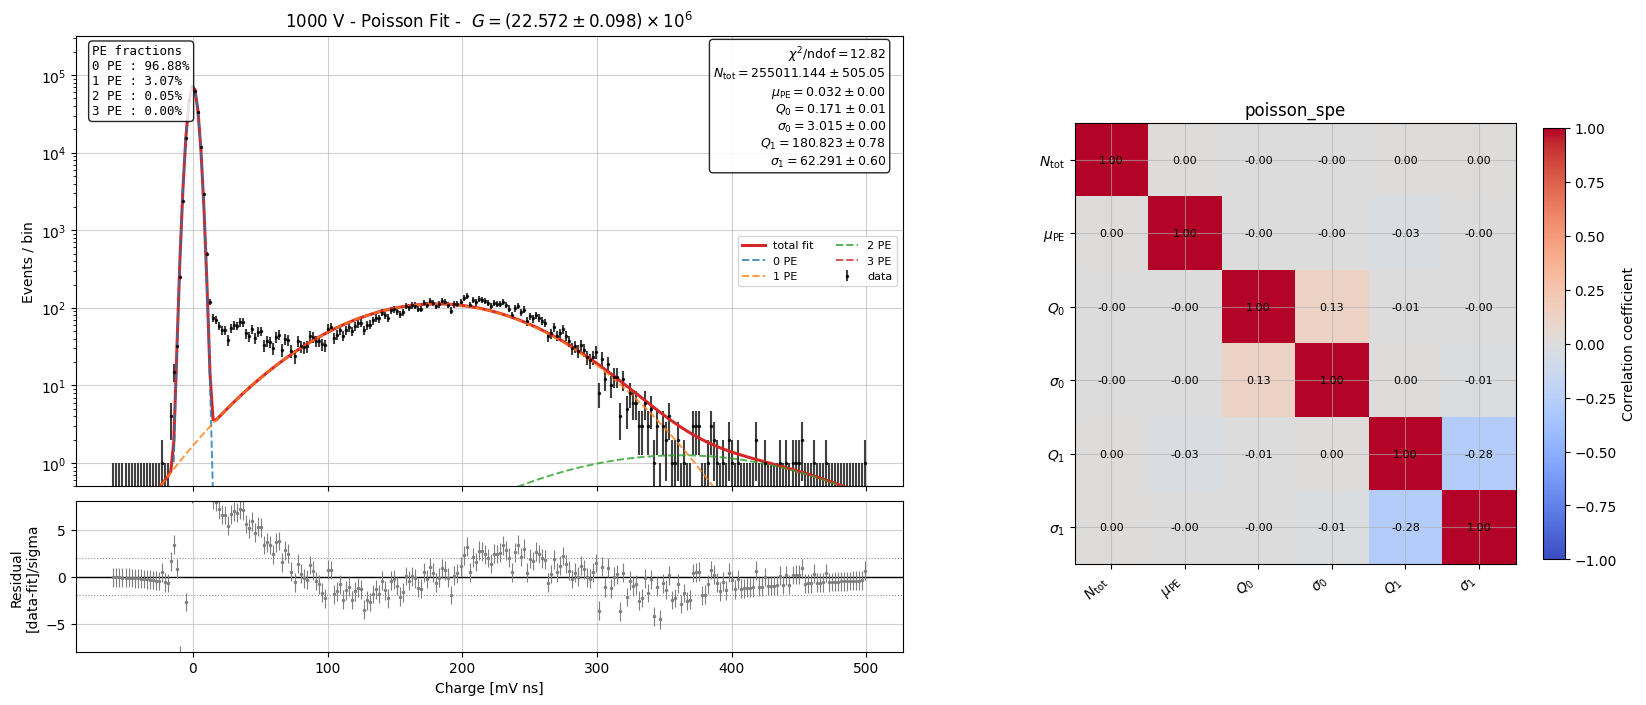

In [16]:
date = "260709"
fit_inputs = f"fit_data/{date}"
save_dir = f'plots/{date}/fit'
with open('config_files/fit_config.yaml') as f:
    cfg = yaml.safe_load(f)

for inputV in np.arange(750, 1001, 25):
    file_name = f"WA0089_{inputV}V_20MHz_led100" 
    fit_charge(inputV, file_name, fit_inputs, cfg, save_dir, fit_model="poisson", default_key="WA0089_20MHz_led100_defaults", lbl=None, save_results=False, initPars=None)




### Bellamy


Loading cached dataframe from fit_data/260709/WA0089_1000V_20MHz_led100_df.pkl
Fit range = [-60, 500]
Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         258087.0000 256218.5322     506.2339   [129043.5, 387130.5]   False
mu_pe                0.0600      0.0285       0.0005             [0.0, 5.0]   False
q0_mV_ns            -1.3000      0.1607       0.0061            [-5.0, 5.0]   False
sigma0_mV_ns         2.6000      3.0067       0.0044            [0.0, 10.0]   False
q1_mV_ns           180.0000    195.1903       0.9646           [5.0, 200.0]   False
sigma1_mV_ns        12.0000     51.9736       0.7460            [1.0, 80.0]   False
w                    0.0100      0.0095       0.0003             [0.0, 1.0]   False
alpha                0.1000      0.0205       0.0016            [0.0, 10.0]   False

 Gain is 2.44e+07 +-1.20e+05 for Q1 = 195.19028525403724


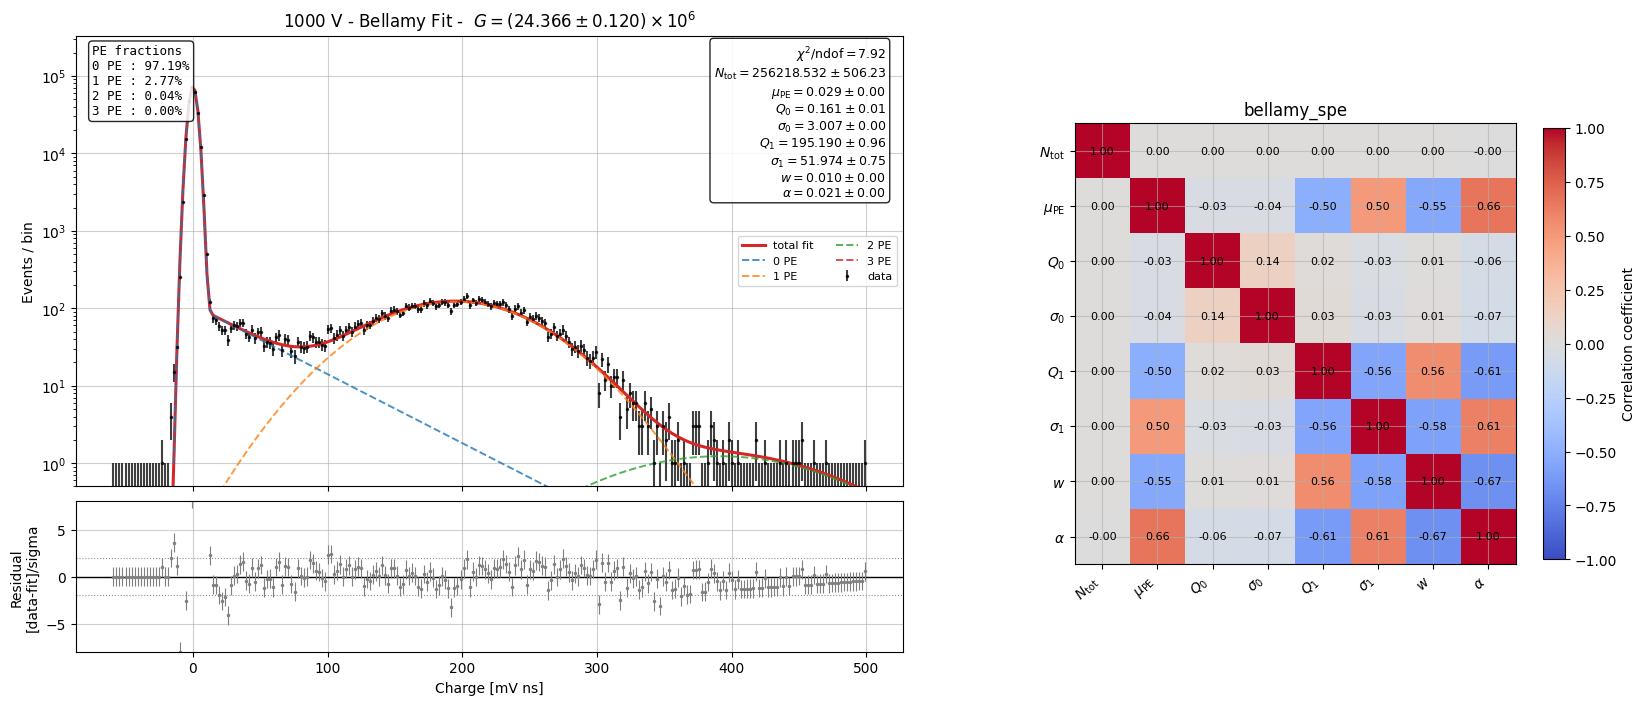

In [17]:
date = "260709"
fit_inputs = f"fit_data/{date}"
save_dir = f'plots/{date}/fit'
with open('config_files/fit_config.yaml') as f:
    cfg = yaml.safe_load(f)

# for inputV in np.arange(750, 1001, 25):
inputV = 1000
file_name = f"WA0089_{inputV}V_20MHz_led100" 

initPars = {
        'q0_mV_ns':     [ -1.3,  -5.0,   5.0,  False],
        'sigma0_mV_ns': [  2.6, '1e-4', 10.0,  False],
        'q1_mV_ns':     [180.0,  5.0,  200.0,  False],
        'sigma1_mV_ns': [12.0,  1.0,   80.0,   False],
        'mu_pe':        [ 0.06, 0.001,  5.0,   False],
        'w':            [ 0.01,  0.0,    1.0,   False],
        'alpha':        [ 0.1,  0.0,   10.0, False]
    }

fit_charge(inputV, file_name, fit_inputs, cfg, save_dir, fit_model="bellamy", default_key="WA0089_20MHz_led100_defaults", lbl=None, save_results=False, initPars=initPars)


Loading cached dataframe from fit_data/260709/WA0089_750V_20MHz_led100_df.pkl
No fit range specified, using full range (np.float64(-20.50187611230649), np.float64(69.33517225878313))
Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         299994.0000 299367.0168     547.1564   [149997.0, 449991.0]   False
mu_pe                0.0600      0.0183       0.0004             [0.0, 5.0]   False
q0_mV_ns            -1.3000     -1.2658       0.0148            [-5.0, 5.0]   False
sigma0_mV_ns         2.6000      2.5712       0.0073            [0.0, 10.0]   False
q1_mV_ns            29.0000     22.8984       0.2608           [5.0, 200.0]   False
sigma1_mV_ns        12.0000      8.9816       0.1999            [1.0, 80.0]   False
w                    1.0000      1.0000       0.0000             [1.0, 1.0]    True
alpha                0.3000      0.6202       0.0059            

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/fit/pdfs.py:15: RuntimeWarning: overflow encountered in exp
  return 0.5 * alpha * np.exp(alpha * (mean - x) + 0.5 * (alpha * sigma) ** 2) * erfc(z)
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/fit/pdfs.py:15: RuntimeWarning: invalid value encountered in multiply
  return 0.5 * alpha * np.exp(alpha * (mean - x) + 0.5 * (alpha * sigma) ** 2) * erfc(z)



Loading cached dataframe from fit_data/260709/WA0089_900V_20MHz_led100_df.pkl
No fit range specified, using full range (np.float64(-20.816147217527035), np.float64(303.2625172329135))
Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         270017.0000 268244.9691     518.9520   [135008.5, 405025.5]   False
mu_pe                0.0600      0.0272       0.0003             [0.0, 5.0]   False
q0_mV_ns            -1.3000     -1.4553       0.0129            [-5.0, 5.0]   False
sigma0_mV_ns         2.6000      2.6192       0.0072            [0.0, 10.0]   False
q1_mV_ns            70.0000     84.8785       0.4803           [5.0, 200.0]   False
sigma1_mV_ns        12.0000     32.9514       0.4301            [1.0, 80.0]   False
w                    1.0000      1.0000       0.0000             [1.0, 1.0]    True
alpha                0.3000      0.5793       0.0040           

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/fit/pdfs.py:15: RuntimeWarning: overflow encountered in exp
  return 0.5 * alpha * np.exp(alpha * (mean - x) + 0.5 * (alpha * sigma) ** 2) * erfc(z)
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/fit/pdfs.py:15: RuntimeWarning: invalid value encountered in multiply
  return 0.5 * alpha * np.exp(alpha * (mean - x) + 0.5 * (alpha * sigma) ** 2) * erfc(z)



Loading cached dataframe from fit_data/260709/WA0089_925V_20MHz_led100_df.pkl
No fit range specified, using full range (np.float64(-22.767747848294675), np.float64(353.59823600994423))
Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         270009.0000 266662.2624     518.5026   [135004.5, 405013.5]   False
mu_pe                0.0600      0.0305       0.0003             [0.0, 5.0]   False
q0_mV_ns            -1.3000     -0.3241       0.0237            [-5.0, 5.0]   False
sigma0_mV_ns         2.6000      2.7549       0.0090            [0.0, 10.0]   False
q1_mV_ns           100.0000    108.8617       0.5889           [5.0, 200.0]   False
sigma1_mV_ns        12.0000     45.1133       0.4474            [1.0, 80.0]   False
w                    0.5000      0.2736       0.0135             [0.0, 1.0]   False
alpha                0.0900      0.4280       0.0064          

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/fit/pdfs.py:15: RuntimeWarning: overflow encountered in exp
  return 0.5 * alpha * np.exp(alpha * (mean - x) + 0.5 * (alpha * sigma) ** 2) * erfc(z)
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/fit/pdfs.py:15: RuntimeWarning: invalid value encountered in multiply
  return 0.5 * alpha * np.exp(alpha * (mean - x) + 0.5 * (alpha * sigma) ** 2) * erfc(z)



Loading cached dataframe from fit_data/260709/WA0089_950V_20MHz_led100_df.pkl
No fit range specified, using full range (np.float64(-16.600970843806863), np.float64(402.6181262804894))
Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         270018.0000 244030.0643     518.4316   [135009.0, 405027.0]   False
mu_pe                0.0600      0.0291       0.0004             [0.0, 5.0]   False
q0_mV_ns            -1.3000     -0.4315       0.0257            [-5.0, 5.0]   False
sigma0_mV_ns         2.6000      2.7282       0.0098            [0.0, 10.0]   False
q1_mV_ns           110.0000    127.7950       0.6530           [5.0, 200.0]   False
sigma1_mV_ns        12.0000     43.1731       0.5561            [1.0, 80.0]   False
w                    0.5000      0.2770       0.0147             [0.0, 1.0]   False
alpha                0.0900      0.4346       0.0067           

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/fit/pdfs.py:15: RuntimeWarning: overflow encountered in exp
  return 0.5 * alpha * np.exp(alpha * (mean - x) + 0.5 * (alpha * sigma) ** 2) * erfc(z)
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/fit/pdfs.py:15: RuntimeWarning: invalid value encountered in multiply
  return 0.5 * alpha * np.exp(alpha * (mean - x) + 0.5 * (alpha * sigma) ** 2) * erfc(z)



Loading cached dataframe from fit_data/260709/WA0089_975V_20MHz_led100_df.pkl
Fit range = [-50, 450]
Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         299944.0000 297708.8294     545.6514   [149972.0, 449916.0]   False
mu_pe                0.0600      0.0284       0.0004             [0.0, 5.0]   False
q0_mV_ns            -1.3000      0.1417       0.0057            [-5.0, 5.0]   False
sigma0_mV_ns         2.6000      2.9834       0.0040            [0.0, 10.0]   False
q1_mV_ns           150.0000    165.8530       0.7806           [5.0, 200.0]   False
sigma1_mV_ns        12.0000     48.7704       0.5914            [1.0, 80.0]   False
w                    0.0100      0.0087       0.0002             [0.0, 1.0]   False
alpha                0.1000      0.0356       0.0022            [0.0, 10.0]   False

 Gain is 2.07e+07 +-9.74e+04 for Q1 = 165.85295255704156

Loa

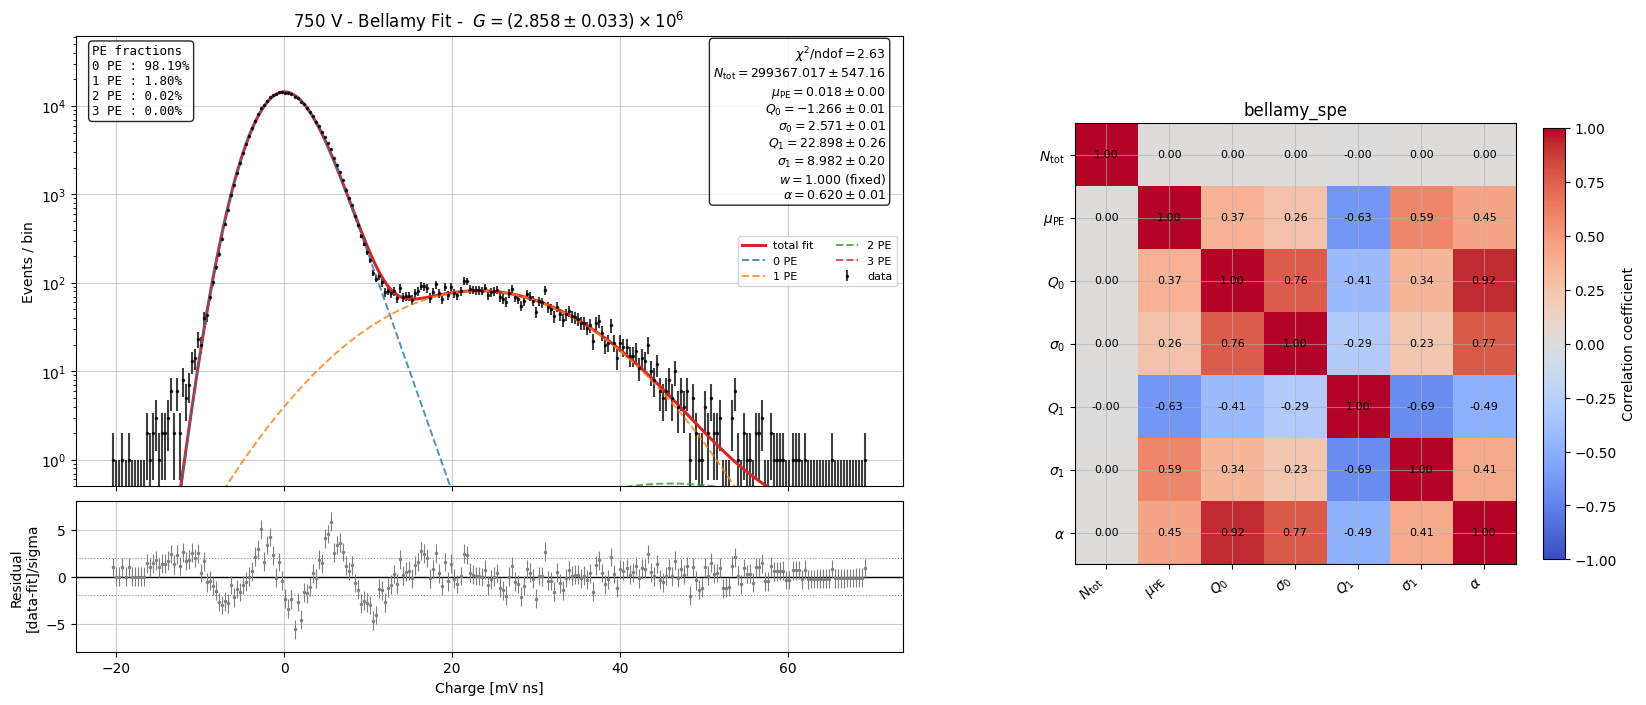

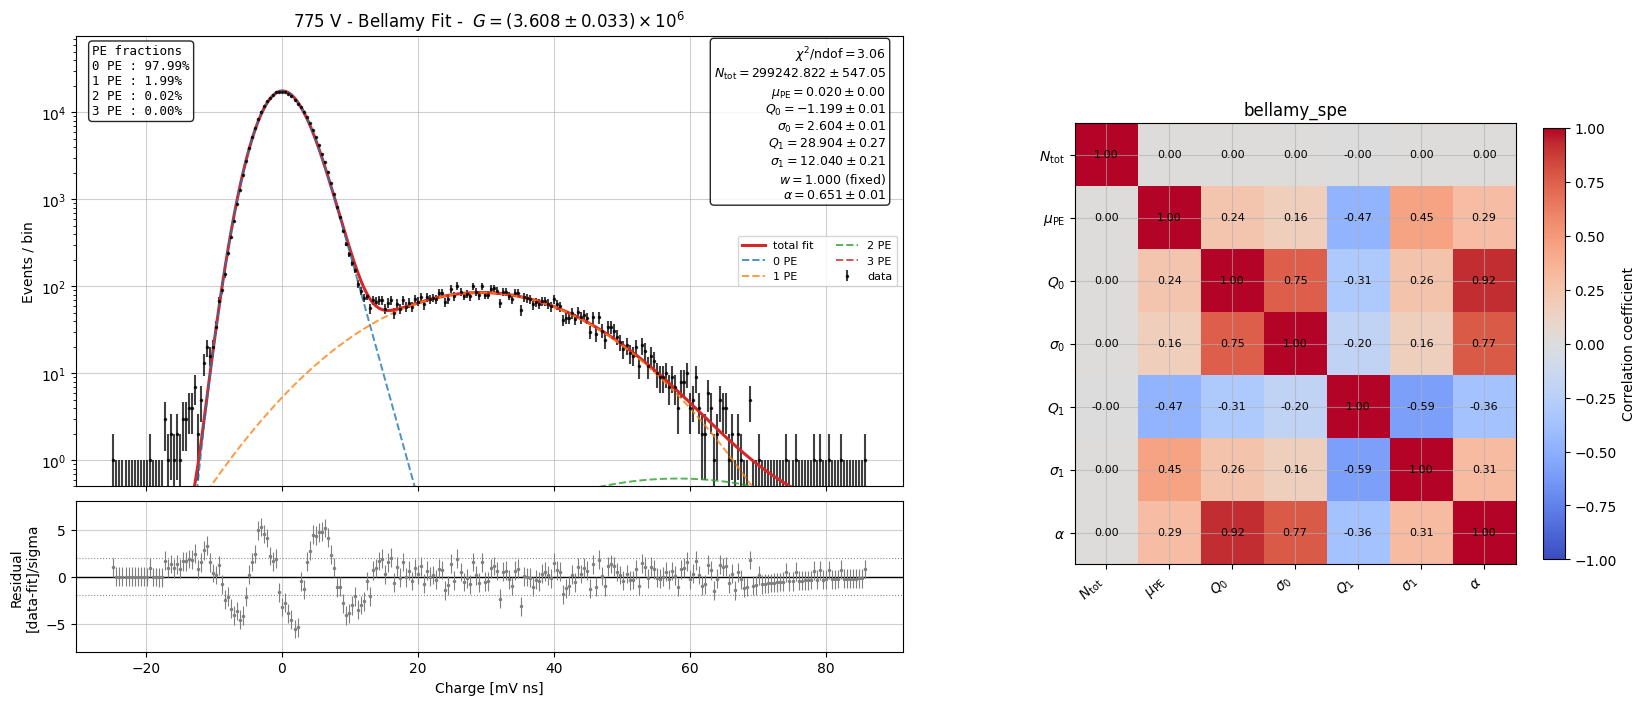

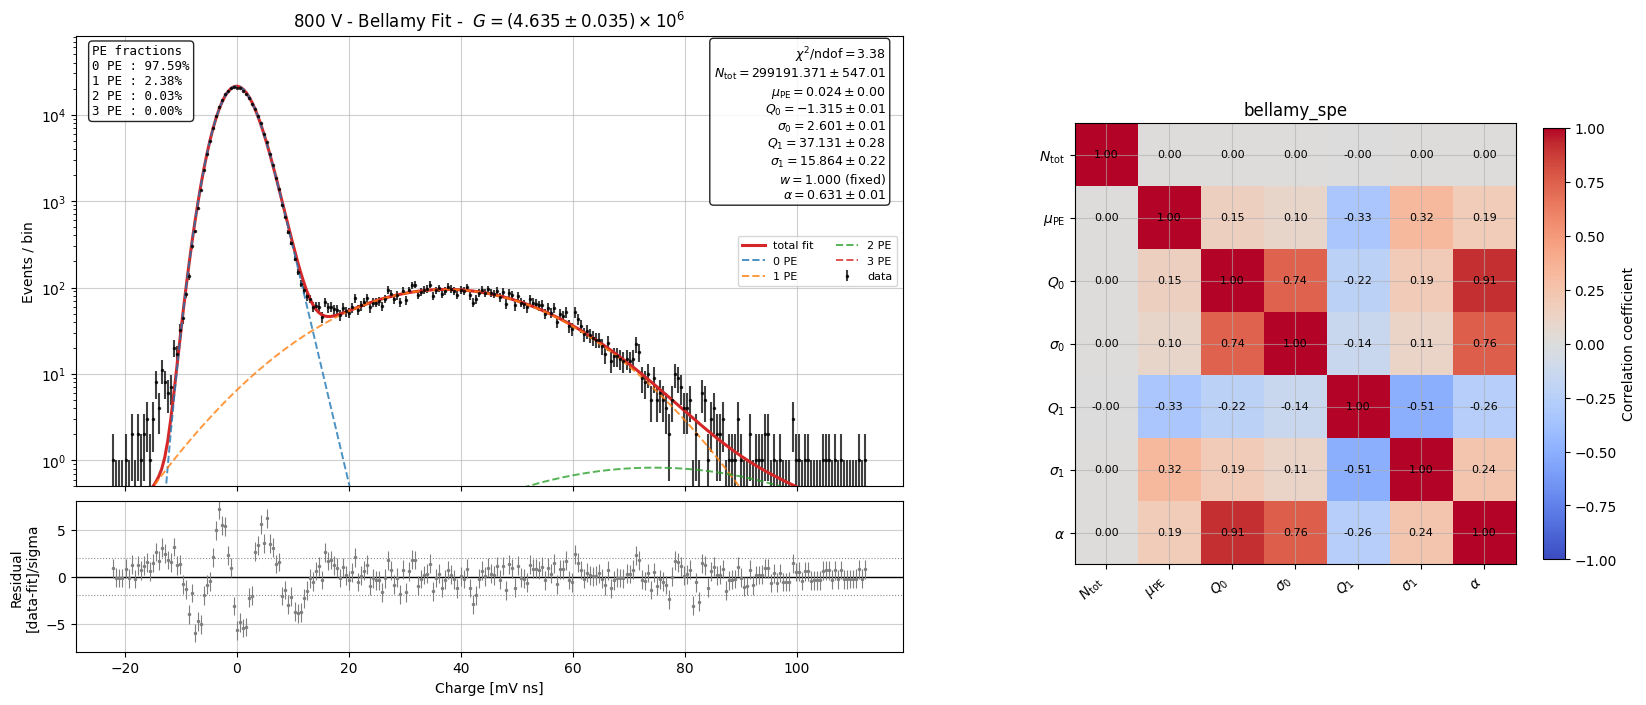

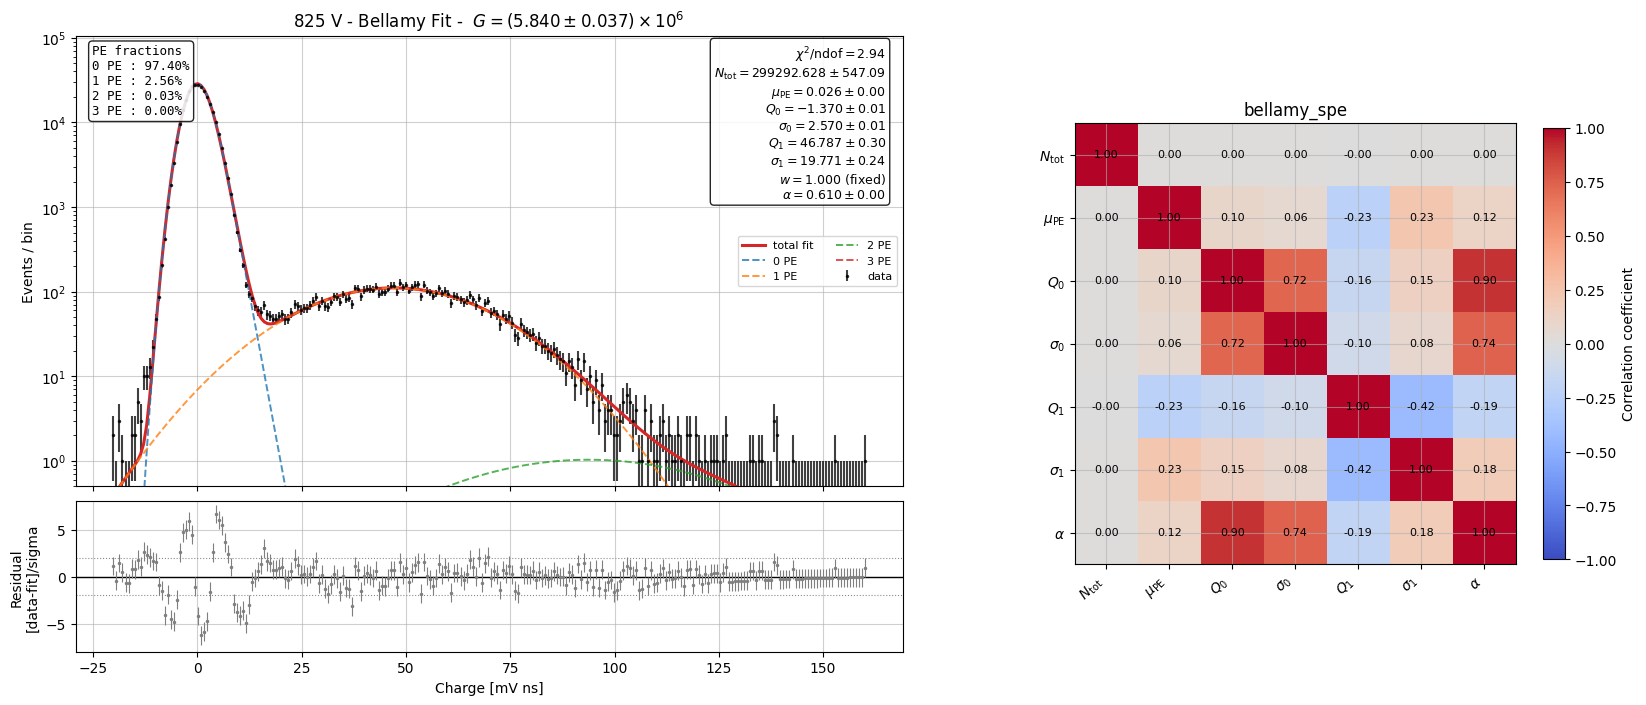

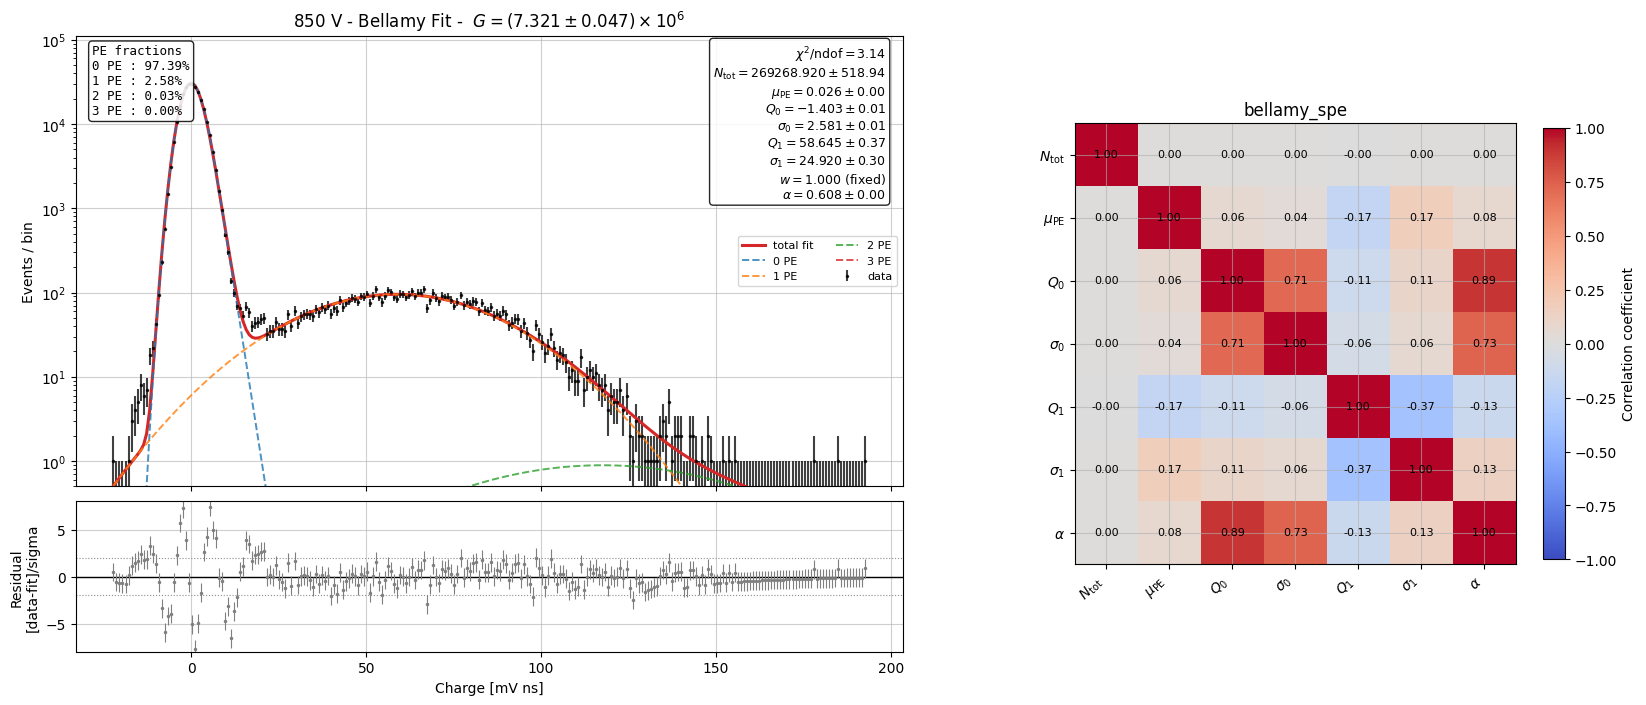

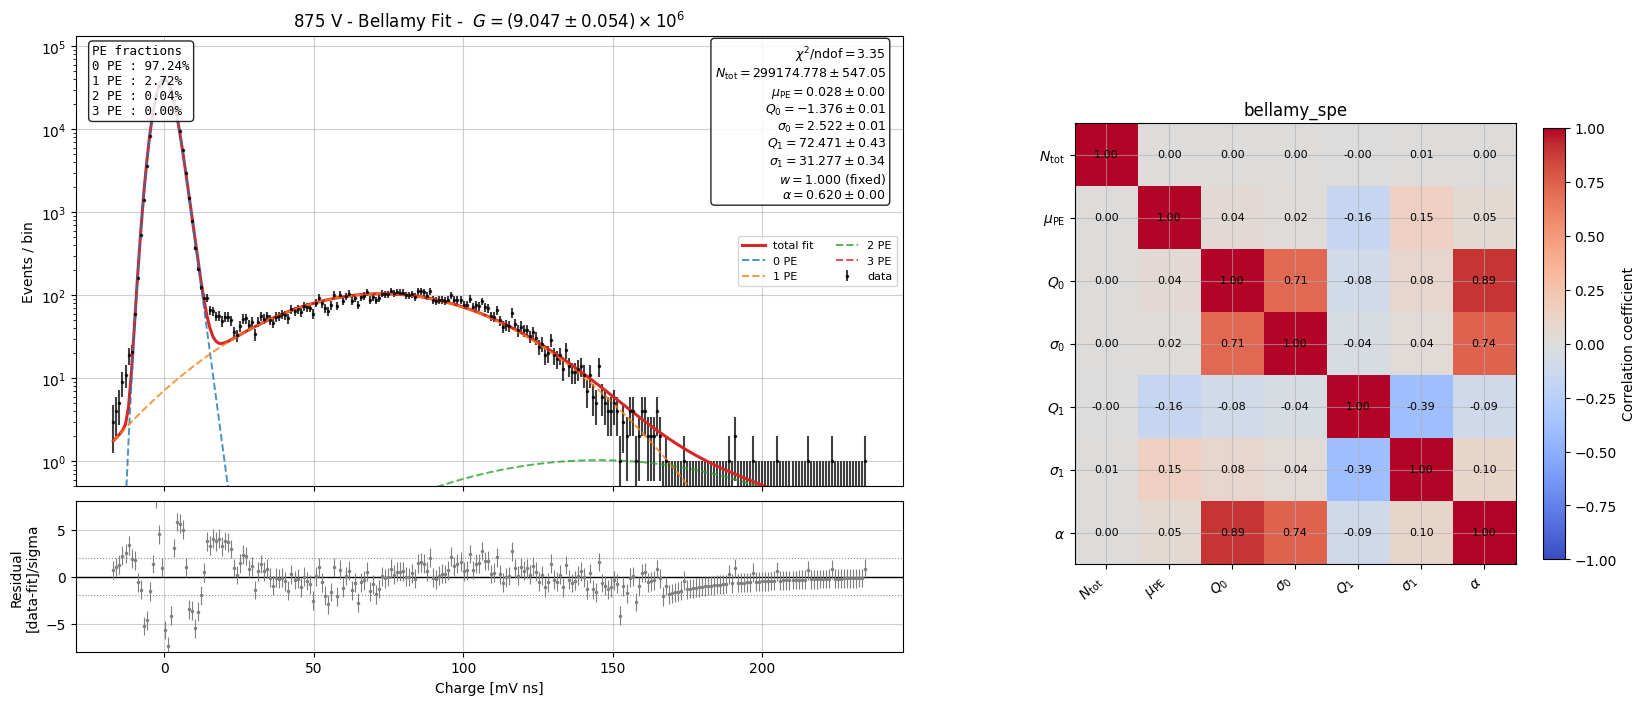

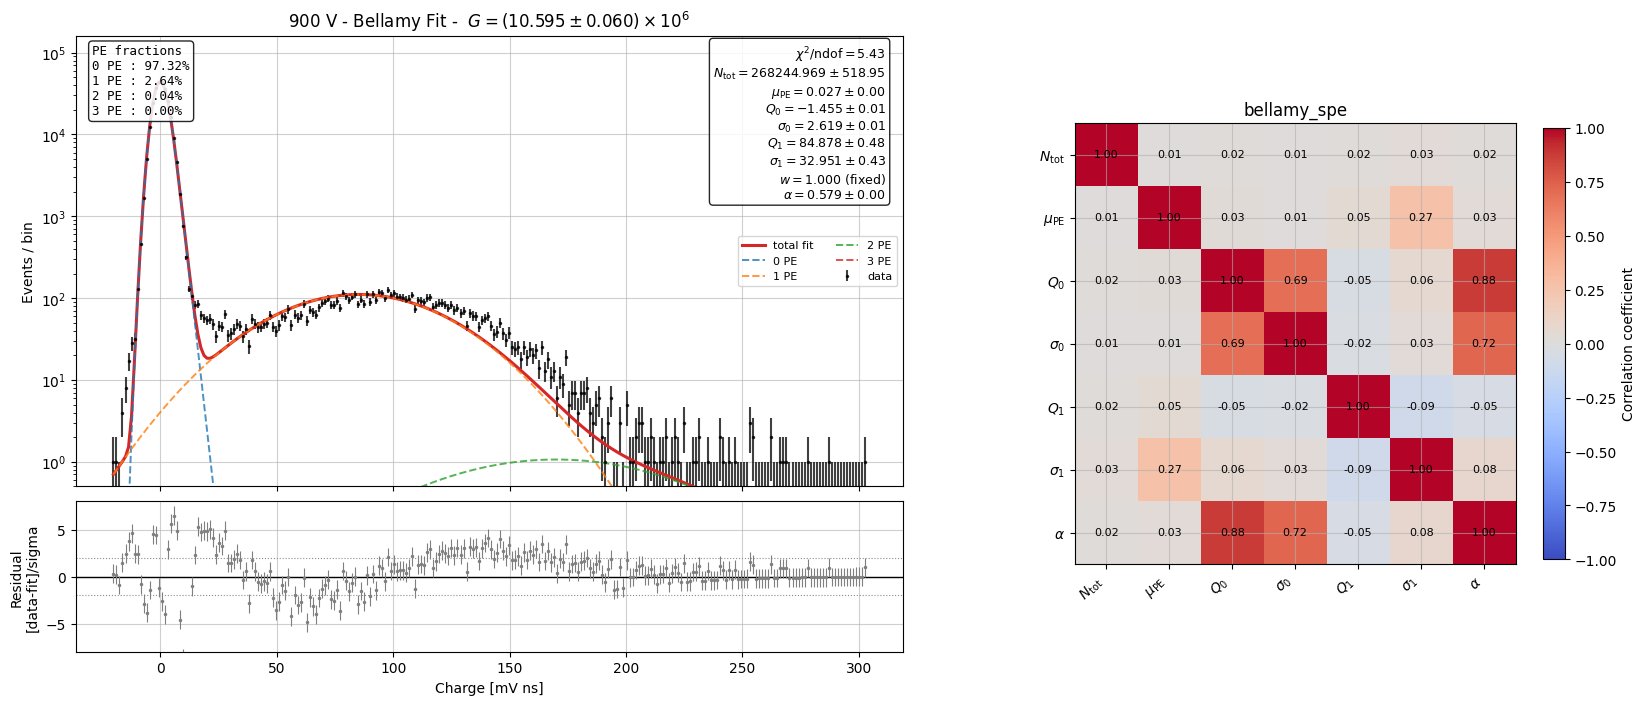

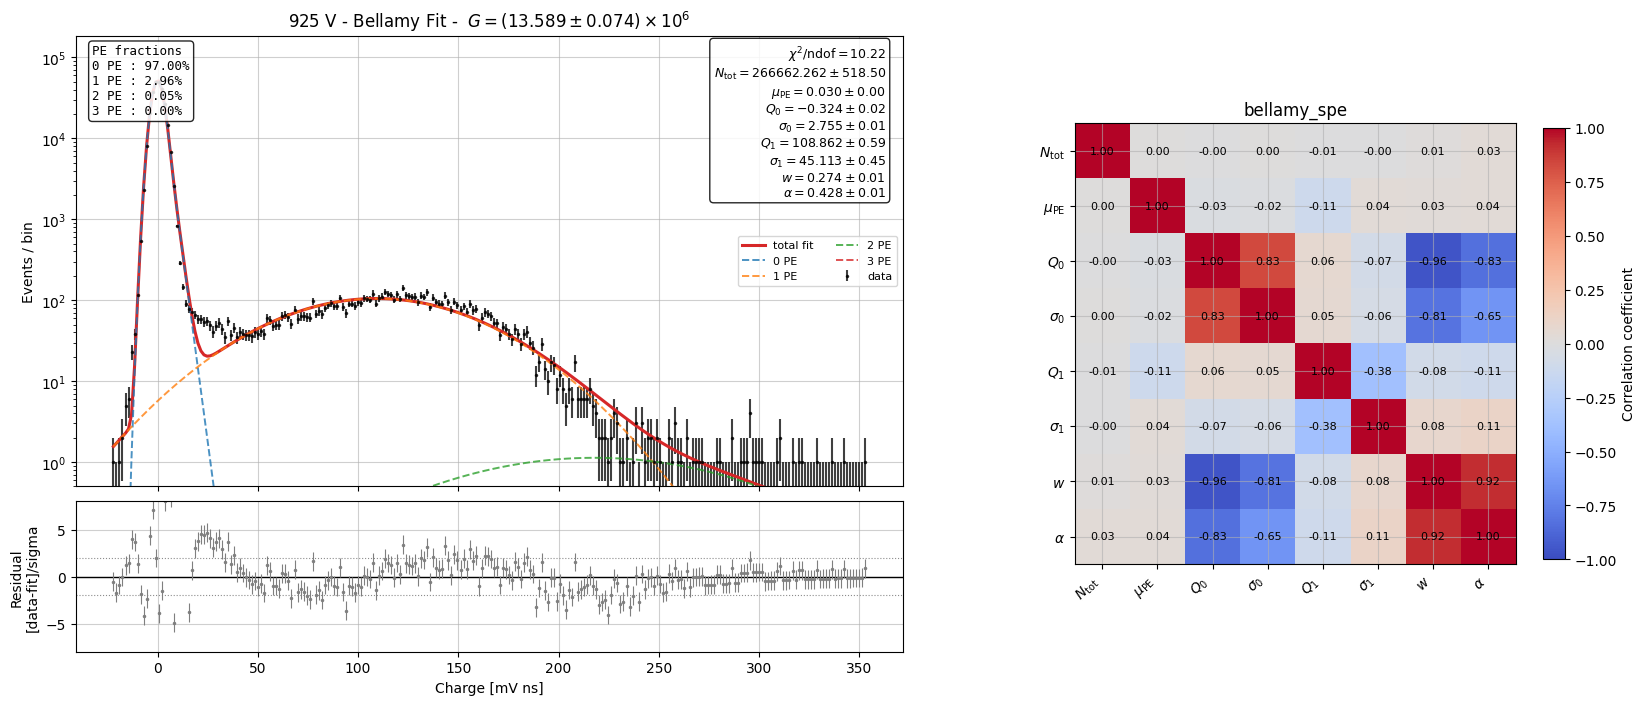

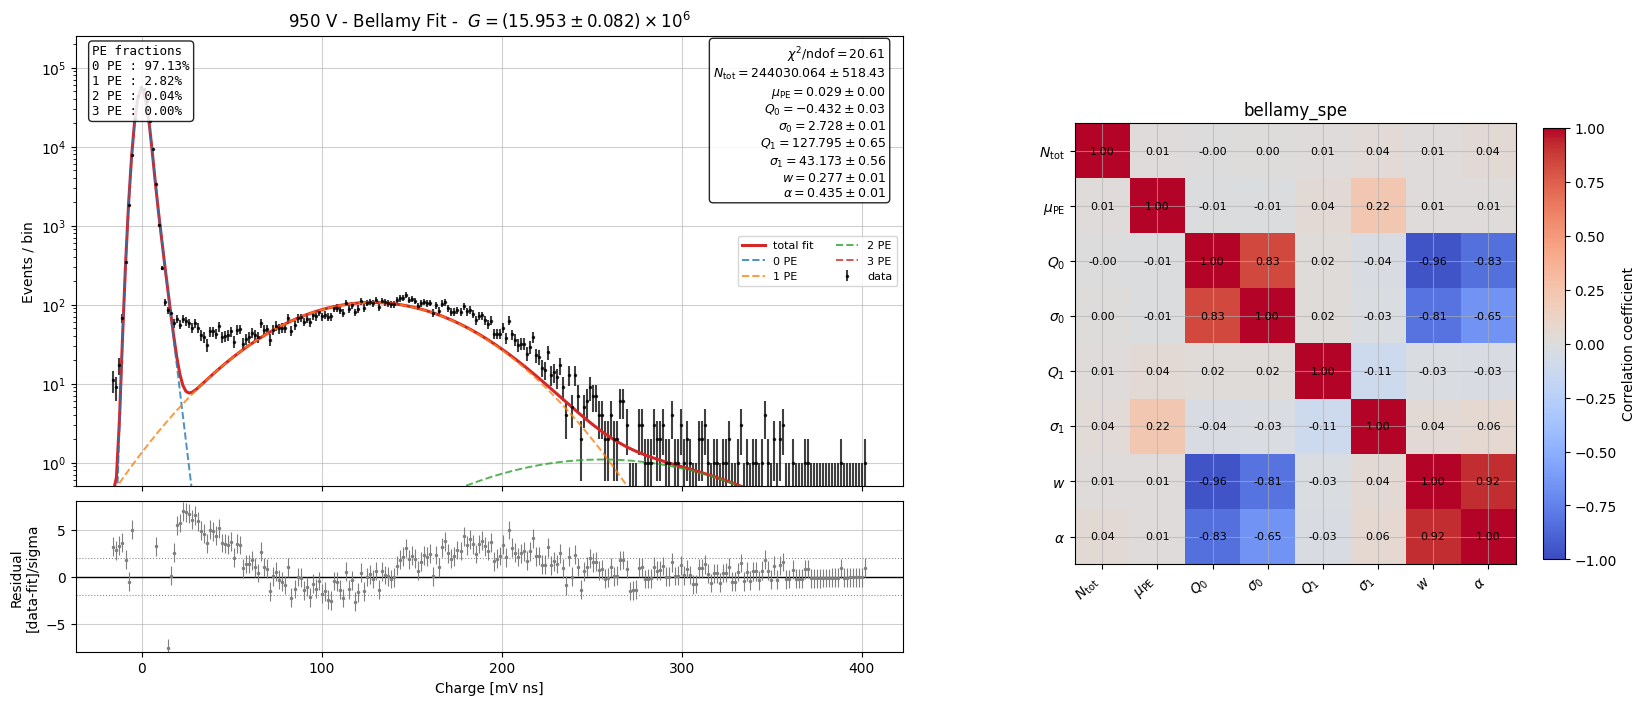

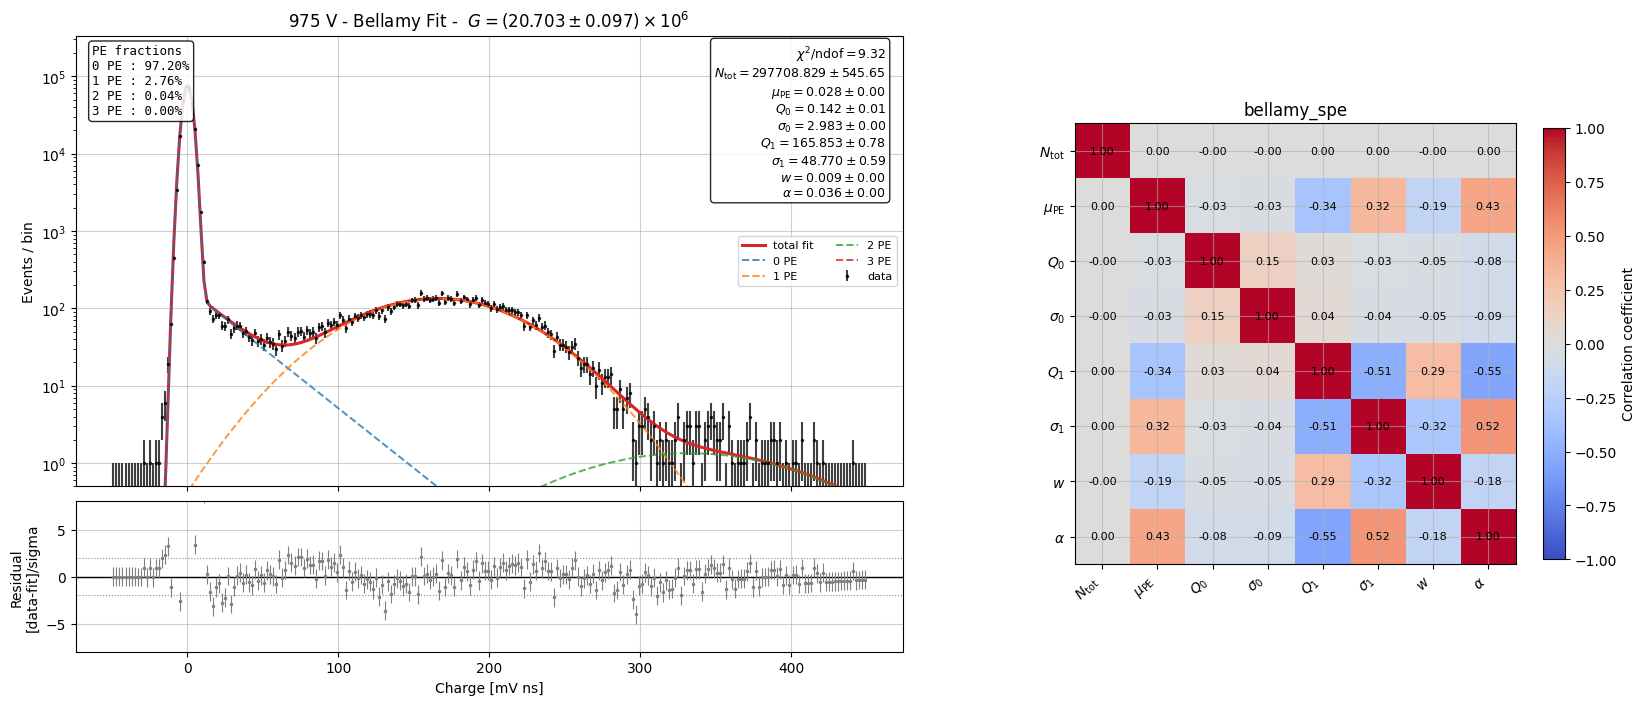

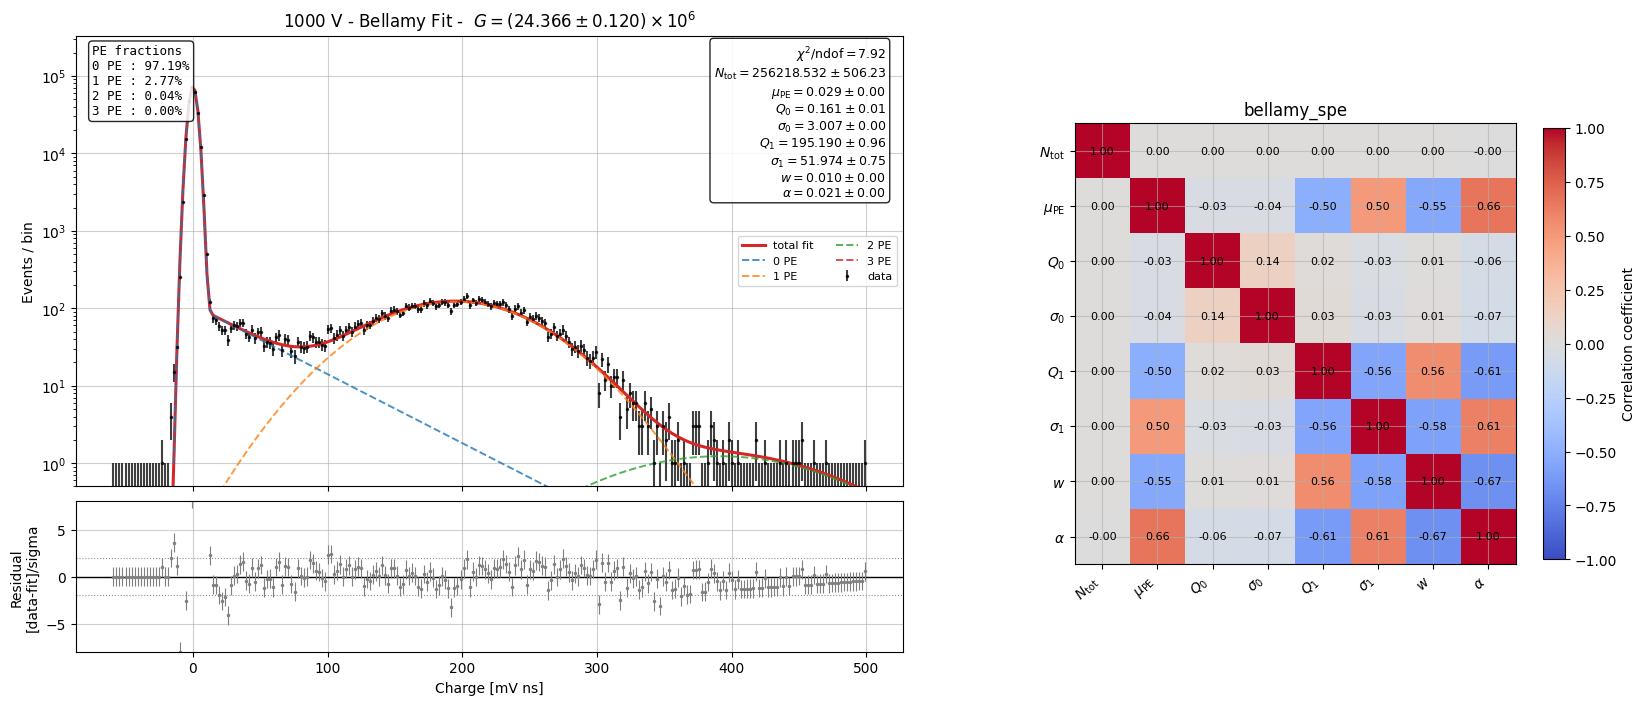

In [21]:
date = "260709"
fit_inputs = f"fit_data/{date}"
save_dir = f'plots/{date}/fit'
with open('config_files/fit_config.yaml') as f:
    cfg = yaml.safe_load(f)

for inputV in np.arange(750, 1001, 25):
# for inputV in np.arange(975, 1001, 25):
    file_name = f"WA0089_{inputV}V_20MHz_led100" 
    fit_charge(inputV, file_name, fit_inputs, cfg, save_dir, fit_model="bellamy", default_key="WA0089_20MHz_led100_defaults", save_results=True)

# Bellamy Scan

In [19]:
# date = "260709"
# fit_inputs = f"fit_data/{date}"
# save_dir = f'plots/{date}/fit_test'
# with open('config_files/fit_config.yaml') as f:
#     cfg = yaml.safe_load(f)

# # for inputV in np.arange(750, 1001, 25):
# inputV = 750
# file_name = f"WA0089_{inputV}V_20MHz_led100" 

# # initPars = get_initPars( cfg, file_name, fit_model="bellamy", default_key="WA0089_20MHz_led100_defaults")

# for w_mean in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
#     initPars = {
#         'q0_mV_ns':     [ 0.3,  -5.0,   5.0, False],
#         'sigma0_mV_ns': [ 3.9, '1e-4', 10.0, False],
#         'q1_mV_ns':     [29.0,  5.0,  200.0, False],
#         'sigma1_mV_ns': [12.0,  1.0,   80.0, False],
#         'mu_pe':        [ 0.06, 0.001,  5.0, False],
#         'w':            [ w_mean,  0.0,    1.0, True],
#         'alpha':        [ 0.3,  0.0,   10.0, False]
#     }
#     # print(int(w_mean*10))
#     fit_charge(inputV, file_name, fit_inputs, cfg, save_dir, fit_model="bellamy", default_key="WA0089_20MHz_led100_defaults", lbl=f'w{int(w_mean*10)}_fixed', save_results=True, initPars=initPars)


In [20]:
# 